# ALZHEIMER EARLY RISK SCREENING SYSTEM


In [ ]:
# CONNECT GOOGLE DRIVE


from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['text_dataset.csv', 'archive (13).zip', 'Colab Notebooks', 'archive (16).zip', 'dementia-20260415T135356Z-3-001 (1).zip', 'nodementia-20260415T135633Z-3-001 (1).zip']


In [ ]:
# UNZIP MRI DATASET

!unzip "/content/drive/MyDrive/archive (13).zip" -d "/content/MRI_DATASET"

Streaming output truncated to the last 5000 lines.
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_102.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_103.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_104.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_105.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_106.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_107.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_108.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_109.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_110.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_111.jpg  
  inflating: /content/MRI_DATASET/Data/Very mild Dementia/OAS1_0247_M

In [ ]:
# CHECK FILES

import os

print(os.listdir('/content/MRI_DATASET'))

['Data']


In [ ]:
# CHECK CLASSES

import os

print(os.listdir('/content/MRI_DATASET/Data'))

['Moderate Dementia', 'Non Demented', 'Mild Dementia', 'Very mild Dementia']


In [ ]:
# IMPORT LIBRARIES

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

In [ ]:

# CONFIGURATION

IMG_SIZE = 128

BATCH_SIZE = 32

EPOCHS = 10

DATASET_PATH = "/content/MRI_DATASET/Data"

MODEL_PATH = "/content/final_mri_model.keras"

CLASS_NAMES = [

    "Mild Dementia",

    "Moderate Dementia",

    "Non Demented",

    "Very mild Dementia"

]

In [ ]:
# MRI DATASET

datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=15,

    zoom_range=0.1,

    horizontal_flip=True

)

train_data = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'

)

val_data = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False

)

Found 69151 images belonging to 4 classes.
Found 17286 images belonging to 4 classes.


In [ ]:
# CREATE SMALL MRI DATASET

import os
import shutil
import random

SOURCE_DIR = "/content/MRI_DATASET/Data"

TARGET_DIR = "/content/SMALL_MRI_DATASET"

MAX_IMAGES_PER_CLASS = 2000

classes = os.listdir(SOURCE_DIR)

for class_name in classes:

    source_class = os.path.join(
        SOURCE_DIR,
        class_name
    )

    target_class = os.path.join(
        TARGET_DIR,
        class_name
    )

    os.makedirs(target_class, exist_ok=True)

    images = os.listdir(source_class)

    # take minimum safely
    sample_size = min(
        len(images),
        MAX_IMAGES_PER_CLASS
    )

    selected_images = random.sample(
        images,
        sample_size
    )

    for image in selected_images:

        src = os.path.join(
            source_class,
            image
        )

        dst = os.path.join(
            target_class,
            image
        )

        shutil.copy(src, dst)

    print(f"{class_name}: {sample_size} images copied")

print("\nSmall Dataset Created Successfully")

Moderate Dementia: 488 images copied
Non Demented: 2000 images copied
Mild Dementia: 2000 images copied
Very mild Dementia: 2000 images copied

Small Dataset Created Successfully


CONFIG

In [ ]:
# CONFIGURATION

IMG_SIZE = 96

BATCH_SIZE = 32

EPOCHS = 5

DATASET_PATH = "/content/SMALL_MRI_DATASET"

MODEL_PATH = "/content/final_mri_model.keras"

MRI DATASET LOADING

In [ ]:
# MRI DATASET

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=15,

    zoom_range=0.1,

    horizontal_flip=True

)

train_data = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'

)

val_data = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False

)

Found 5191 images belonging to 4 classes.
Found 1297 images belonging to 4 classes.


BUILD MODEL

In [ ]:
# MRI MODEL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(96,96,3)

)

base_model.trainable = False

mri_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(128, activation='relu'),

    Dense(4, activation='softmax')

])

mri_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

mri_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

TRAINING

In [ ]:
# TRAIN MRI MODEL

from tensorflow.keras.callbacks import (

    EarlyStopping,

    ModelCheckpoint

)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=2,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    MODEL_PATH,

    monitor='val_accuracy',

    save_best_only=True

)

history = mri_model.fit(

    train_data,

    validation_data=val_data,

    epochs=EPOCHS,

    callbacks=[

        early_stop,

        checkpoint

    ]

)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 305ms/step - accuracy: 0.5144 - loss: 1.1037 - val_accuracy: 0.4911 - val_loss: 1.2104
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.5970 - loss: 0.9381 - val_accuracy: 0.5089 - val_loss: 1.1755
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.6114 - loss: 0.8824 - val_accuracy: 0.5127 - val_loss: 1.1035
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.6427 - loss: 0.8360 - val_accuracy: 0.5335 - val_loss: 1.1113
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.6502 - loss: 0.8123 - val_accuracy: 0.5628 - val_loss: 1.0776


Fine-Tuning

In [ ]:
# FINE TUNING

base_model.trainable = True

for layer in base_model.layers[:-20]:

    layer.trainable = False

mri_model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

fine_tune_history = mri_model.fit(

    train_data,

    validation_data=val_data,

    epochs=3

)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 235ms/step - accuracy: 0.5072 - loss: 1.7014 - val_accuracy: 0.5490 - val_loss: 1.1141
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.5825 - loss: 1.1371 - val_accuracy: 0.5443 - val_loss: 1.1606
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.5891 - loss: 0.9911 - val_accuracy: 0.5520 - val_loss: 1.1697


EVALUATION

In [ ]:
# EVALUATION

loss, accuracy = mri_model.evaluate(val_data)

print("Final Fine-Tuned Accuracy:", accuracy)

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.5412 - loss: 1.1708
Final Fine-Tuned Accuracy: 0.5412490367889404


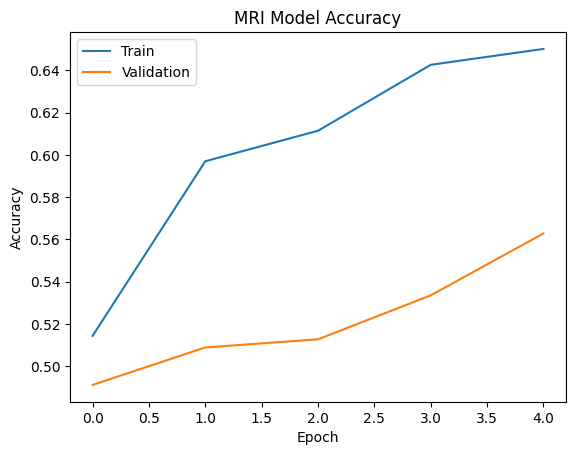

In [ ]:
# ACCURACY GRAPH

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("MRI Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([

    "Train",

    "Validation"

])

plt.show()

LOSS GRAPH

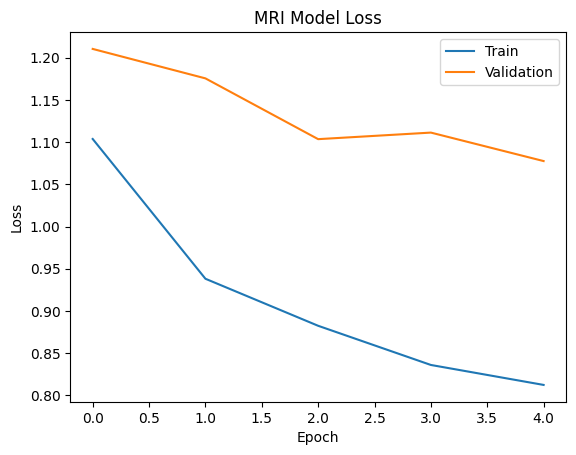

In [ ]:
# LOSS GRAPH

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("MRI Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([

    "Train",

    "Validation"

])

plt.show()

MRI Prediction System

In [ ]:
# MRI PREDICTION SYSTEM

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

CLASS_NAMES = [

    "Mild Dementia",

    "Moderate Dementia",

    "Non Demented",

    "Very mild Dementia"

]

def predict_mri(img_path):

    img = load_img(

        img_path,

        target_size=(96,96)

    )

    img_array = img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(

        img_array,

        axis=0

    )

    prediction = mri_model.predict(img_array)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    print("\n========================")

    print(" MRI ANALYSIS RESULT ")

    print("========================")

    print(
        "Prediction:",
        CLASS_NAMES[predicted_class]
    )

    print(
        "Confidence:",
        round(float(confidence),2)
    )

    return prediction

In [ ]:
import os

folder = "/content/SMALL_MRI_DATASET/Non Demented"

print(os.listdir(folder)[:5])

['OAS1_0340_MR1_mpr-1_131.jpg', 'OAS1_0202_MR2_mpr-1_130.jpg', 'OAS1_0174_MR1_mpr-4_107.jpg', 'OAS1_0107_MR1_mpr-1_139.jpg', 'OAS1_0234_MR1_mpr-4_133.jpg']


CONFUSION MATRIX

41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step


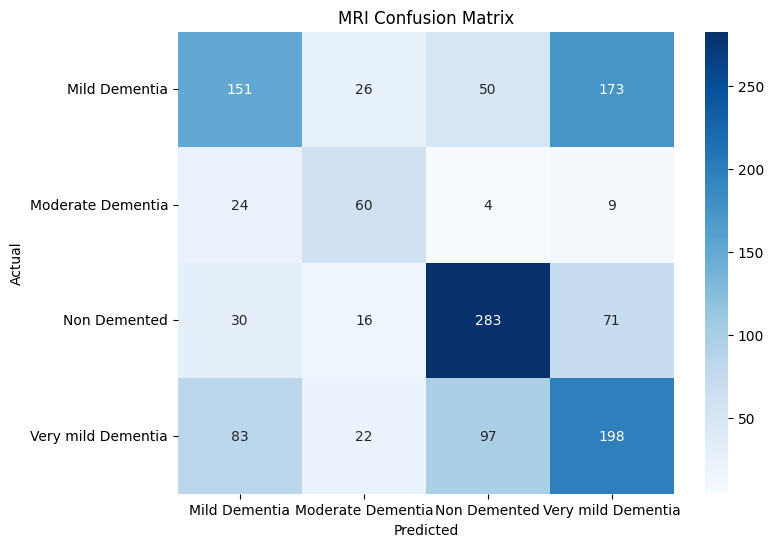

In [ ]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = mri_model.predict(val_data)

predicted_classes = np.argmax(

    predictions,

    axis=1

)

true_classes = val_data.classes

cm = confusion_matrix(

    true_classes,

    predicted_classes

)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.title("MRI Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

GRAD-CAM

In [ ]:
print(mri_model.inputs)
print(mri_model.outputs)

[<KerasTensor shape=(None, 96, 96, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_154>]
[<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_159>]


In [ ]:
# FUNCTIONAL MRI MODEL

import tensorflow as tf
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

# INPUT

inputs = Input(shape=(96,96,3))

# BASE MODEL

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_tensor=inputs

)

base_model.trainable = False

# TOP LAYERS

x = GlobalAveragePooling2D()(base_model.output)

x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)

outputs = Dense(4, activation='softmax')(x)

# FINAL MODEL

mri_model = Model(

    inputs,

    outputs

)

# COMPILE

mri_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

mri_model.summary()

/tmp/ipykernel_474/3199872344.py:22: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mri_model.fit(
    train_data,
    validation_data=val_data,
    epochs=1
)

163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 204ms/step - accuracy: 0.4783 - loss: 1.2229 - val_accuracy: 0.4595 - val_loss: 1.1789


Using image for Grad-CAM: /content/SMALL_MRI_DATASET/Moderate Dementia/OAS1_0308_MR1_mpr-1_155.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


<Figure size 600x600 with 0 Axes>

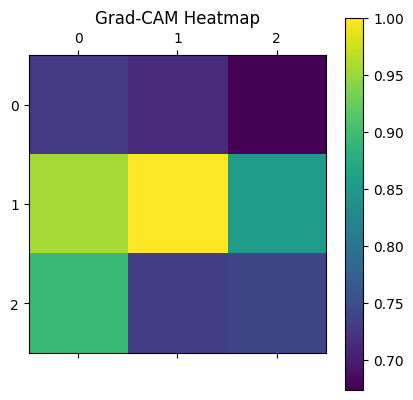

In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Dynamically select an image to ensure correct path
small_mri_dir = "/content/SMALL_MRI_DATASET"

# Get a list of class folders (e.g., 'Non Demented', 'Mild Dementia')
class_folders = [d for d in os.listdir(small_mri_dir) if os.path.isdir(os.path.join(small_mri_dir, d))]

if not class_folders:
    raise FileNotFoundError(f"No class folders found in {small_mri_dir}")

# Choose a random class folder
selected_class_folder = random.choice(class_folders)
full_class_path = os.path.join(small_mri_dir, selected_class_folder)

# Get all image files in the selected class folder
image_files = [f for f in os.listdir(full_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

if not image_files:
    raise FileNotFoundError(f"No image files found in {full_class_path}")

# Choose a random image file
selected_image_file = random.choice(image_files)
img_path = os.path.join(full_class_path, selected_image_file)

print(f"Using image for Grad-CAM: {img_path}")

# LOAD IMAGE
img = load_img(
    img_path,
    target_size=(96,96)
)

img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

# PREDICTION

preds = mri_model.predict(img_array)

pred_index = np.argmax(preds[0])

# LAST CONV LAYER

last_conv_layer = base_model.get_layer("Conv_1")

# GRAD MODEL

grad_model = tf.keras.models.Model(

    inputs=mri_model.input,

    outputs=[

        last_conv_layer.output,

        mri_model.output

    ]

)

# COMPUTE GRADIENTS

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, pred_index]

grads = tape.gradient(
    loss,
    conv_outputs
)

# MEAN GRADIENTS

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

# FEATURE MAP

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(
    heatmap,
    0
)

heatmap /= np.max(heatmap)

# DISPLAY

plt.figure(figsize=(6,6))

plt.matshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.colorbar()

plt.show()

In [ ]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report
import numpy as np

# PREDICTIONS

predictions = mri_model.predict(val_data)

y_pred = np.argmax(
    predictions,
    axis=1
)

# TRUE LABELS

y_true = val_data.classes

# CLASS NAMES

class_names = list(
    val_data.class_indices.keys()
)

# REPORT

report = classification_report(

    y_true,

    y_pred,

    target_names=class_names

)

print(report)

41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step
                    precision    recall  f1-score   support

     Mild Dementia       0.47      0.51      0.49       400
 Moderate Dementia       0.00      0.00      0.00        97
      Non Demented       0.49      0.76      0.60       400
Very mild Dementia       0.44      0.28      0.34       400

          accuracy                           0.47      1297
         macro avg       0.35      0.39      0.36      1297
      weighted avg       0.43      0.47      0.44      1297



تحسين الصور

In [ ]:
# شوف ترتيب الكلاسات
print(train_data.class_indices)

{'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}


In [ ]:
# إنشاء Dataset ثنائي لـ MRI (Demented vs NonDemented)

import os
import shutil
import glob

SOURCE_MRI_DIR = "/content/SMALL_MRI_DATASET"
TARGET_BINARY_MRI_DIR = "/content/BINARY_MRI_DATASET"

# إنشاء المجلدات الهدف إذا لم تكن موجودة
os.makedirs(os.path.join(TARGET_BINARY_MRI_DIR, "Demented"), exist_ok=True)
os.makedirs(os.path.join(TARGET_BINARY_MRI_DIR, "NonDemented"), exist_ok=True)

# الفئات التي تعتبر 'مصابة بالخرف' (Demented)
demented_classes = [
    "Mild Dementia",
    "Moderate Dementia",
    "Very mild Dementia"
]

# الفئات التي تعتبر 'غير مصابة بالخرف' (NonDemented)
non_demented_classes = [
    "Non Demented"
]

print("Creating BINARY_MRI_DATASET...")

# نقل صور الخرف
for d_class in demented_classes:
    source_path = os.path.join(SOURCE_MRI_DIR, d_class)
    target_path = os.path.join(TARGET_BINARY_MRI_DIR, "Demented")
    if os.path.exists(source_path):
        for img_file in os.listdir(source_path):
            shutil.copy(os.path.join(source_path, img_file), target_path)
        print(f"Copied {len(os.listdir(source_path))} images from '{d_class}' to 'Demented'.")

# نقل صور غير الخرف
for nd_class in non_demented_classes:
    source_path = os.path.join(SOURCE_MRI_DIR, nd_class)
    target_path = os.path.join(TARGET_BINARY_MRI_DIR, "NonDemented")
    if os.path.exists(source_path):
        for img_file in os.listdir(source_path):
            shutil.copy(os.path.join(source_path, img_file), target_path)
        print(f"Copied {len(os.listdir(source_path))} images from '{nd_class}' to 'NonDemented'.")

print("BINARY_MRI_DATASET created successfully.")
print(f"Total Demented images: {len(os.listdir(os.path.join(TARGET_BINARY_MRI_DIR, 'Demented')))}")
print(f"Total NonDemented images: {len(os.listdir(os.path.join(TARGET_BINARY_MRI_DIR, 'NonDemented')))}")

Creating BINARY_MRI_DATASET...
Copied 2000 images from 'Mild Dementia' to 'Demented'.
Copied 488 images from 'Moderate Dementia' to 'Demented'.
Copied 2000 images from 'Very mild Dementia' to 'Demented'.
Copied 2000 images from 'Non Demented' to 'NonDemented'.
BINARY_MRI_DATASET created successfully.
Total Demented images: 4488
Total NonDemented images: 2000


AUC Score: 0.769
Optimal Threshold: 0.0803

بدل score < 0.5 استخدم score < 0.0803

MRI Accuracy with new threshold: 29.0%
              precision    recall  f1-score   support

 NonDemented       0.32      0.37      0.34       100
    Demented       0.25      0.21      0.23       100

    accuracy                           0.29       200
   macro avg       0.28      0.29      0.29       200
weighted avg       0.28      0.29      0.29       200



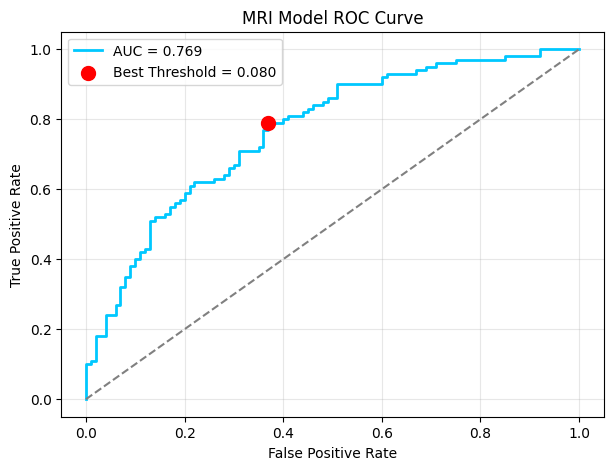

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import glob

all_scores, all_true = [], []

for img_path in glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")[:100]:
    img = np.array(__import__('PIL').Image.open(img_path).convert("RGB").resize((96,96))).astype("float32") / 255.0
    score = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    all_scores.append(score)
    all_true.append(1)  # Demented

for img_path in glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*.jpg")[:100]:
    img = np.array(__import__('PIL').Image.open(img_path).convert("RGB").resize((96,96))).astype("float32") / 255.0
    score = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    all_scores.append(score)
    all_true.append(0)  # NonDemented

# score < threshold = Demented
# إيجاد أفضل threshold
fpr, tpr, thresholds = roc_curve(all_true, all_scores)
auc = roc_auc_score(all_true, all_scores)

# أفضل threshold = أقرب نقطة لـ (0,1)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"AUC Score: {auc:.3f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"\nبدل score < 0.5 استخدم score < {optimal_threshold:.4f}")

# اختبار بالـ threshold الجديد
preds_new = [1 if s < optimal_threshold else 0 for s in all_scores]
print(f"\nMRI Accuracy with new threshold: {accuracy_score(all_true, preds_new)*100:.1f}%")
print(classification_report(all_true, preds_new, target_names=['NonDemented','Demented']))

# رسم ROC
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='#00c8ff', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1], 'gray', linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, zorder=5, label=f'Best Threshold = {optimal_threshold:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MRI Model ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# إعادة تدريب MRI Model - محسّن

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BINARY_PATH = "/content/BINARY_MRI_DATASET"
IMG_SIZE    = 96
BATCH_SIZE  = 32

# ---- Data Augmentation ----
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_gen.flow_from_directory(
    BINARY_PATH, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='training', shuffle=True, seed=42
)
val_data = val_gen.flow_from_directory(
    BINARY_PATH, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    subset='validation', shuffle=False, seed=42
)

print("Class indices:", train_data.class_indices)
# {'Demented': 0, 'NonDemented': 1}
# يعني output قريب من 0 = Demented, قريب من 1 = NonDemented

# Class Weights
d = len(glob.glob(f"{BINARY_PATH}/Demented/*.jpg"))
n = len(glob.glob(f"{BINARY_PATH}/NonDemented/*.jpg"))
total = d + n
class_weight = {0: total/(2*d), 1: total/(2*n)}
print(f"Class weights: {class_weight}")

# بناء النموذج
base = MobileNetV2(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE,IMG_SIZE,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
out = Dense(1, activation='sigmoid')(x)

mri_model = Model(base.input, out)
mri_model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# ---- Phase 1 ----
print("\n🚀 Phase 1: Training top layers...")
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    ModelCheckpoint("/content/final_mri_model.keras",
                    monitor='val_auc', save_best_only=True, mode='max')
]

mri_model.fit(train_data, validation_data=val_data,
              epochs=15, callbacks=callbacks,
              class_weight=class_weight)

#Phase 2 Fine-tuning
print("\n🔥 Phase 2: Fine-tuning...")
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

mri_model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

mri_model.fit(train_data, validation_data=val_data,
              epochs=10, callbacks=callbacks,
              class_weight=class_weight)


loss, acc, auc = mri_model.evaluate(val_data, verbose=0)
print(f"\n{'='*40}")
print(f"  MRI Accuracy : {acc*100:.1f}%")
print(f"  MRI AUC      : {auc:.3f}")
print(f"{'='*40}")

Found 5191 images belonging to 2 classes.
Found 1297 images belonging to 2 classes.
Class indices: {'Demented': 0, 'NonDemented': 1}
Class weights: {0: 0.7228163992869875, 1: 1.622}

🚀 Phase 1: Training top layers...
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 244ms/step - accuracy: 0.6766 - auc: 0.7315 - loss: 0.6767 - val_accuracy: 0.8103 - val_auc: 0.8228 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.7372 - auc: 0.8081 - loss: 0.5406 - val_accuracy: 0.8219 - val_auc: 0.8402 - val_loss: 0.4919 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - accuracy: 0.7690 - auc: 0.8331 - loss: 0.5006 - val_accuracy: 0.7911 - val_auc: 0.8492 - val_loss: 0.5212 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.7846 - auc: 0.8479 - loss: 0.4831 - val_accuracy: 0.8049 - val_auc: 0.8595 - val_loss: 0.5060 - learning_rate: 0.0010
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━

In [ ]:
print(type(base_model))
print(base_model.name)

for layer in base_model.layers[-8:]:
    print(f"{layer.name:45s} {type(layer).__name__}")

<class 'keras.src.models.functional.Functional'>
functional_26
out_relu                                      ReLU
global_average_pooling2d_2                    GlobalAveragePooling2D
batch_normalization                           BatchNormalization
dense_6                                       Dense
dropout_3                                     Dropout
dense_7                                       Dense
dropout_4                                     Dropout
dense_8                                       Dense


Heatmap: (300, 300)


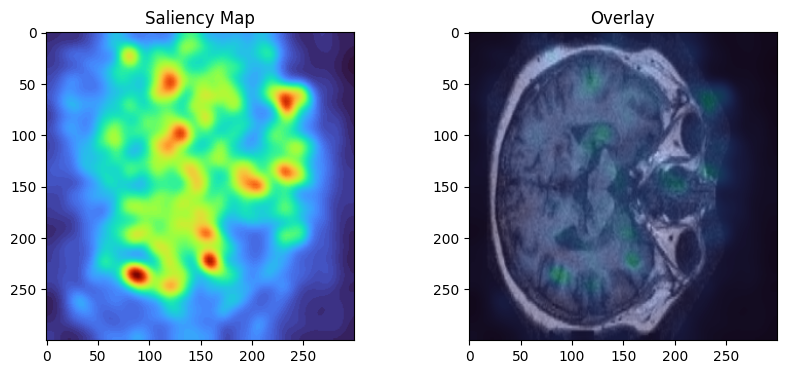


MRI Accuracy: 76.9%
              precision    recall  f1-score   support

 NonDemented       0.89      0.61      0.73        80
    Demented       0.70      0.93      0.80        80

    accuracy                           0.77       160
   macro avg       0.80      0.77      0.76       160
weighted avg       0.80      0.77      0.76       160


✅ Ready — run CELL 9!


In [ ]:
# ✅ النموذج الجديد — طبقاته مباشرة فيه
# آخر طبقة Conv هي Conv_1 في index 151

# تحديث base_model — مو محتاجه، نستخدم mri_model مباشرة
base_model = mri_model  # نفس الشي الحين

# Grad-CAM (Saliency Map) — مصلح نهائي - Moved from cell 61HctHV7yzc8
import tensorflow as tf
import numpy as np
import cv2
import os
from PIL import Image

def safe_gradcam(image_pil):
    try:
        if image_pil is None:
            return None, None
        tmp = "/tmp/gc.jpg"
        image_pil.convert("RGB").save(tmp)
        img = np.array(image_pil.convert("RGB").resize((96,96))).astype("float32") / 255.0
        img_tf = tf.Variable(np.expand_dims(img, 0))
        with tf.GradientTape() as tape:
            tape.watch(img_tf)
            preds = mri_model(img_tf, training=False)
            loss  = preds[:, 0]
        grads   = tape.gradient(loss, img_tf).numpy()[0]
        heatmap = np.mean(np.abs(grads), axis=-1)
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmap = cv2.GaussianBlur(heatmap, (11,11), 0)
        orig    = cv2.cvtColor(cv2.imread(tmp), cv2.COLOR_BGR2RGB)
        orig    = cv2.resize(orig, (300,300))
        hm_r    = cv2.resize(heatmap, (300,300))
        hm_col  = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_TURBO), cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(orig, 0.65, hm_col, 0.35, 0)
        return np.uint8(hm_r*255), overlay
    except Exception as e:
        print(f"Grad-CAM Error: {e}")
        return None, None


# اختبار Grad-CAM
import glob
from PIL import Image
imgs = glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")
test_img = Image.open(imgs[0])
h, o = safe_gradcam(test_img)
print("Heatmap:", h.shape if h is not None else "FAILED")

if h is not None:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    ax[0].imshow(h, cmap='turbo'); ax[0].set_title("Saliency Map")
    ax[1].imshow(o); ax[1].set_title("Overlay")
    plt.show()

# اختبار دقة
all_scores, all_true = [], []
for img_path in glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")[:80]:
    img = np.array(Image.open(img_path).convert("RGB").resize((96,96))).astype("float32") / 255.0
    score = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    all_scores.append(score); all_true.append(1)

for img_path in glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*.jpg")[:80]:
    img = np.array(Image.open(img_path).convert("RGB").resize((96,96))).astype("float32") / 255.0
    score = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    all_scores.append(score); all_true.append(0)

preds = [1 if s < 0.5 else 0 for s in all_scores]
print(f"\nMRI Accuracy: {accuracy_score(all_true, preds)*100:.1f}%")
print(classification_report(all_true, preds, target_names=['NonDemented','Demented']))
print("\n✅ Ready — run CELL 9!")

Heatmap: (300, 300)


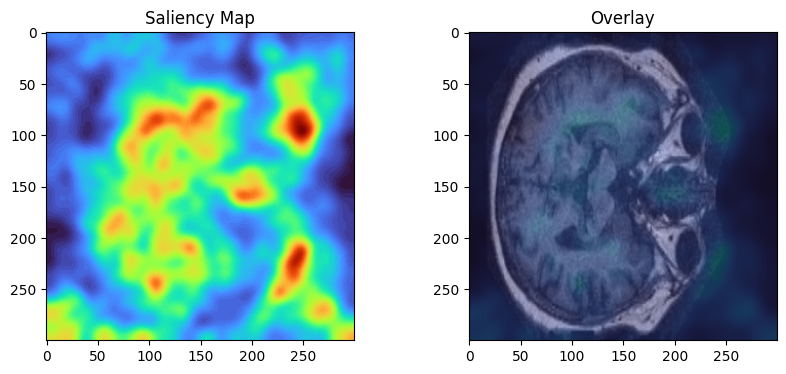

In [ ]:
def safe_gradcam(image_pil):
    try:
        if image_pil is None:
            return None, None

        tmp_path = "/tmp/gradcam_in.jpg"
        image_pil.convert("RGB").save(tmp_path)

        img = np.array(image_pil.convert("RGB").resize((96, 96))).astype("float32") / 255.0
        img_array = np.expand_dims(img, axis=0)
        img_tf = tf.Variable(img_array)

        #
        with tf.GradientTape() as tape:
            tape.watch(img_tf)
            preds = mri_model(img_tf, training=False)
            loss  = preds[:, 0]

        # Gradient على الـ input
        grads = tape.gradient(loss, img_tf)  # shape: (1, 96, 96, 3)

        # تحويل الـ gradient لـ heatmap
        grads_np = grads.numpy()[0]  # (96, 96, 3)
        heatmap  = np.mean(np.abs(grads_np), axis=-1)  # (96, 96)
        heatmap  = np.maximum(heatmap, 0)

        if np.max(heatmap) > 1e-8:
            heatmap /= np.max(heatmap)
        else:
            print("Empty heatmap")
            return None, None

        heatmap = cv2.GaussianBlur(heatmap, (11,11), 0)
        orig    = cv2.imread(tmp_path)
        orig    = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        orig    = cv2.resize(orig, (300,300))
        hm_r    = cv2.resize(heatmap, (300,300))
        hm_col  = cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_TURBO)
        hm_col  = cv2.cvtColor(hm_col, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(orig, 0.65, hm_col, 0.35, 0)

        return np.uint8(hm_r*255), overlay

    except Exception as e:
        print(f"Grad-CAM Error: {e}")
        import traceback; traceback.print_exc()
        return None, None

# اختبار
import glob
from PIL import Image
imgs = glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")
test_img = Image.open(imgs[0])
h, o = safe_gradcam(test_img)
print("Heatmap:", h.shape if h is not None else "FAILED")

if h is not None:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    ax[0].imshow(h, cmap='turbo'); ax[0].set_title("Saliency Map")
    ax[1].imshow(o); ax[1].set_title("Overlay")
    plt.show()

الصوت

In [ ]:
# INSTALL LIBRARIES

!pip install librosa --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['text_dataset.csv', 'archive (13).zip', 'Colab Notebooks', 'archive (16).zip', 'dementia-20260415T135356Z-3-001 (1).zip', 'nodementia-20260415T135633Z-3-001 (1).zip']


In [ ]:
!unzip "/content/drive/MyDrive/archive (16).zip" -d /content/audio_dataset

Archive:  /content/drive/MyDrive/archive (16).zip
  inflating: /content/audio_dataset/addetector_dataset.csv  


In [ ]:
import os

print(os.listdir('/content/audio_dataset'))

['addetector_dataset.csv']


In [ ]:
!unzip "/content/drive/MyDrive/dementia-20260415T135356Z-3-001 (1).zip" -d /content/audio_dataset/

!unzip "/content/drive/MyDrive/nodementia-20260415T135633Z-3-001 (1).zip" -d /content/audio_dataset/

Archive:  /content/drive/MyDrive/dementia-20260415T135356Z-3-001 (1).zip
  inflating: /content/audio_dataset/dementia/Abe Burrows/AbeBurrows_5.wav  
  inflating: /content/audio_dataset/dementia/Estelle Getty/EstelleGetty_15.wav  
  inflating: /content/audio_dataset/dementia/Ronald Reagan/RonaldReagan_10.wav  
  inflating: /content/audio_dataset/dementia/Ian McCaskill/ianmccaskill_15.wav  
  inflating: /content/audio_dataset/dementia/Ronald Reagan/RonaldReagan_5.wav  
  inflating: /content/audio_dataset/dementia/Woody Durham/woodydurham_0_2.wav  
  inflating: /content/audio_dataset/dementia/George Robb/georgerobb_10.wav  
  inflating: /content/audio_dataset/dementia/Trevor Peacock/TrevorPeacock_5.wav  
  inflating: /content/audio_dataset/dementia/Ronan O_Rahilly/ronano_rahilly_15_2.wav  
  inflating: /content/audio_dataset/dementia/Stan Bowles/StanBowles_5.wav  
  inflating: /content/audio_dataset/dementia/Unita Blackwell/UnitaBlackwell_15.wav  
  inflating: /content/audio_dataset/demen

In [ ]:
import os

print(os.listdir("/content/audio_dataset"))

['nodementia', 'addetector_dataset.csv', 'dementia']


In [ ]:

import os
import numpy as np
import librosa
from tqdm import tqdm


# DATASET PATHS

DEMENTIA_PATH = "/content/audio_dataset/dementia"
NONDEMENTIA_PATH = "/content/audio_dataset/nodementia"

# SETTINGS

SAMPLE_RATE = 22050
MFCC_FEATURES = 40
MAX_PAD_LEN = 300

# FUNCTION TO EXTRACT MFCC

def extract_mfcc(file_path):

    try:

        audio, sample_rate = librosa.load(
            file_path,
            sr=SAMPLE_RATE
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=MFCC_FEATURES
        )

        # Padding / Trimming

        if mfcc.shape[1] < MAX_PAD_LEN:

            pad_width = MAX_PAD_LEN - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                pad_width=((0,0),(0,pad_width)),
                mode='constant'
            )

        else:

            mfcc = mfcc[:, :MAX_PAD_LEN]

        return mfcc

    except Exception as e:

        print("Error:", file_path)
        return None


# LOAD DATA

X = []
y = []

# Dementia Files

for file in tqdm(os.listdir(DEMENTIA_PATH)):

    if file.endswith(".wav"):

        file_path = os.path.join(DEMENTIA_PATH, file)

        mfcc = extract_mfcc(file_path)

        if mfcc is not None:

            X.append(mfcc)
            y.append(1)

# Non Dementia Files

for file in tqdm(os.listdir(NONDEMENTIA_PATH)):

    if file.endswith(".wav"):

        file_path = os.path.join(NONDEMENTIA_PATH, file)

        mfcc = extract_mfcc(file_path)

        if mfcc is not None:

            X.append(mfcc)
            y.append(0)

# CONVERT TO NUMPY

X = np.array(X)
y = np.array(y)

# Add channel dimension

X = X[..., np.newaxis]

print("\n======================")
print("DATASET READY")
print("======================")

print("X shape:", X.shape)
print("y shape:", y.shape)

100%|██████████| 95/95 [00:00<00:00, 770713.50it/s]


DATASET READY
X shape: (0, 1)
y shape: (0,)


In [ ]:
import os

print(os.listdir("/content/audio_dataset/dementia")[:10])

print(os.listdir("/content/audio_dataset/nodementia")[:10])

['Omar Sharif', 'Jonathan Miller', 'Unita Blackwell', 'Pauline Phillips', 'Stan Bowles', 'Dan Ingram', 'Paul Hornung', 'B B King', 'Ray Galton', 'Ronan O_Rahilly']
['Linda Evans', 'George H W Bush', 'David McCallum', 'Sam Waterston', 'Paul Michael Glaser', 'Jane Fonda', 'Tina turner', 'Robert Vaughn', 'Rosalynn Carter', 'Michel Piccoli']


In [ ]:
# IMPORT LIBRARIES

import os
import numpy as np
import librosa
from tqdm import tqdm


# DATASET PATHS

DEMENTIA_PATH = "/content/audio_dataset/dementia"
NONDEMENTIA_PATH = "/content/audio_dataset/nodementia"

# SETTINGS

SAMPLE_RATE = 22050
MFCC_FEATURES = 40
MAX_PAD_LEN = 300

SUPPORTED_FORMATS = (".wav", ".mp3", ".m4a", ".flac")


# FUNCTION TO EXTRACT MFCC

def extract_mfcc(file_path):

    try:

        audio, sample_rate = librosa.load(
            file_path,
            sr=SAMPLE_RATE
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=MFCC_FEATURES
        )

        # Padding

        if mfcc.shape[1] < MAX_PAD_LEN:

            pad_width = MAX_PAD_LEN - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                pad_width=((0,0),(0,pad_width)),
                mode='constant'
            )

        else:

            mfcc = mfcc[:, :MAX_PAD_LEN]

        return mfcc

    except:

        return None

# LOAD DATA

X = []
y = []

# DEMENTIA

for person in tqdm(os.listdir(DEMENTIA_PATH)):

    person_path = os.path.join(DEMENTIA_PATH, person)

    if os.path.isdir(person_path):

        for file in os.listdir(person_path):

            if file.lower().endswith(SUPPORTED_FORMATS):

                file_path = os.path.join(person_path, file)

                mfcc = extract_mfcc(file_path)

                if mfcc is not None:

                    X.append(mfcc)
                    y.append(1)

# NON DEMENTIA

for person in tqdm(os.listdir(NONDEMENTIA_PATH)):

    person_path = os.path.join(NONDEMENTIA_PATH, person)

    if os.path.isdir(person_path):

        for file in os.listdir(person_path):

            if file.lower().endswith(SUPPORTED_FORMATS):

                file_path = os.path.join(person_path, file)

                mfcc = extract_mfcc(file_path)

                if mfcc is not None:

                    X.append(mfcc)
                    y.append(0)

# CONVERT TO NUMPY

X = np.array(X)
y = np.array(y)

# Add channel dimension

X = X[..., np.newaxis]

print("\n======================")
print("DATASET READY")
print("======================")

print("X shape:", X.shape)
print("y shape:", y.shape)

100%|██████████| 95/95 [00:43<00:00,  2.17it/s]


DATASET READY
X shape: (348, 40, 300, 1)
y shape: (348,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# =========================================================
# AUDIO MODEL
# =========================================================

audio_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(40, 300, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # For binary classification (dementia/non-dementia)
])

audio_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

audio_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 298, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 149, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 147, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 73, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37376)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,784,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,803,201 (18.32 MB)

 Trainable params: 4,803,201 (18.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# SPLIT DATASET


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# TRAIN MODEL

history = audio_model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=20,

    batch_size=16

)

X_train shape: (278, 40, 300, 1)
X_test shape: (70, 40, 300, 1)
y_train shape: (278,)
y_test shape: (70,)
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.6079 - loss: 23.7642 - val_accuracy: 0.5857 - val_loss: 0.6800
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5971 - loss: 0.6784 - val_accuracy: 0.5714 - val_loss: 0.6996
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7050 - loss: 0.6731 - val_accuracy: 0.5714 - val_loss: 0.6776
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7662 - loss: 0.5737 - val_accuracy: 0.5714 - val_loss: 0.6837
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8417 - loss: 0.4356 - val_accuracy: 0.6143 - val_loss: 0.9337
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9137 - loss: 0.2494 - val_accuracy: 0.6143 - val_loss: 1.0662
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9640 - loss: 0.1477 - val_accuracy: 0.6571 - val_loss: 0.8562
Ep

In [ ]:
# IMPORT LIBRARIES

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import numpy as np

# PREDICTIONS

y_pred_prob = audio_model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

# CLASSIFICATION REPORT

print("\n======================")
print("CLASSIFICATION REPORT")
print("======================\n")

print(classification_report(

    y_test,
    y_pred,

    target_names=[
        "NonDementia",
        "Dementia"
    ]

))

# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n======================")
print("CONFUSION MATRIX")
print("======================\n")

print(cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step

CLASSIFICATION REPORT

              precision    recall  f1-score   support

 NonDementia       0.60      0.71      0.65        38
    Dementia       0.56      0.44      0.49        32

    accuracy                           0.59        70
   macro avg       0.58      0.57      0.57        70
weighted avg       0.58      0.59      0.58        70


CONFUSION MATRIX

[[27 11]
 [18 14]]


In [ ]:
audio_model.save("/content/final_audio_model.keras")

print("✅ Audio Model Saved Successfully")

✅ Audio Model Saved Successfully


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'final_audio_model.keras', 'drive', 'audio_dataset', 'SMALL_MRI_DATASET', 'final_mri_model.keras', 'MRI_DATASET', 'BINARY_MRI_DATASET', 'sample_data']


In [ ]:
import os

person_path = "/content/audio_dataset/dementia/Don Lane"

print(os.listdir(person_path)[:10])

['DonLane_0.wav']


In [ ]:
# IMPORT LIBRARIES

import librosa
import numpy as np

from tensorflow.keras.models import load_model


# LOAD MODEL

audio_model = load_model(
    "/content/final_audio_model.keras"
)

# AUDIO PATH

audio_path = "/content/audio_dataset/dementia/Don Lane/DonLane_0.wav"

# SETTINGS

SAMPLE_RATE = 22050

MFCC_FEATURES = 40

MAX_PAD_LEN = 300

# LOAD AUDIO

audio, sample_rate = librosa.load(

    audio_path,

    sr=SAMPLE_RATE

)

# EXTRACT MFCC

mfcc = librosa.feature.mfcc(

    y=audio,

    sr=sample_rate,

    n_mfcc=MFCC_FEATURES

)

# PADDING / TRIMMING
if mfcc.shape[1] < MAX_PAD_LEN:

    pad_width = MAX_PAD_LEN - mfcc.shape[1]

    mfcc = np.pad(

        mfcc,

        pad_width=((0,0),(0,pad_width)),

        mode='constant'

    )

else:

    mfcc = mfcc[:, :MAX_PAD_LEN]

# RESHAPE

mfcc = mfcc.reshape(

    1,
    40,
    300,
    1

)

# PREDICTION

prediction = audio_model.predict(mfcc)[0][0]

# RESULT

if prediction > 0.5:

    label = "Dementia"

    confidence = prediction

else:

    label = "NonDementia"

    confidence = 1 - prediction

print("\n======================")
print(" AUDIO ANALYSIS RESULT ")
print("======================")

print(f"Prediction: {label}")

print(f"Confidence: {confidence:.2f}")

print("\nRaw Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step

 AUDIO ANALYSIS RESULT 
Prediction: Dementia
Confidence: 1.00

Raw Prediction: 0.9999989


النص

In [ ]:
import pandas as pd

# LOAD DATASET

df = pd.read_csv("/content/drive/MyDrive/text_dataset.csv")

# SHOW DATA

print(df.head())

print("\n====================")

print(df.columns)

print("\n====================")

print(df.shape)

                                                text  label
0        I struggle to remember recent conversations      1
1  Lately i forgot my appointment again this afte...      1
2  Sometimes i keep asking the same question repe...      1
3  Sometimes i could not remember my neighbor's n...      1
4              I forgot why I entered the room today      1

Index(['text', 'label'], dtype='object')

(200, 2)


In [ ]:


import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# LOAD DATASET

df = pd.read_csv(
    "/content/drive/MyDrive/text_dataset.csv"
)

# INPUTS & LABELS

X = df["text"]

y = df["label"]

# TF-IDF VECTORIZATION

vectorizer = TfidfVectorizer(

    stop_words='english',

    max_features=5000

)

X_vectorized = vectorizer.fit_transform(X)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X_vectorized,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

# BUILD MODEL

text_model = LogisticRegression()


# TRAIN MODEL

text_model.fit(

    X_train,

    y_train

)

# PREDICTIONS

y_pred = text_model.predict(X_test)

# ACCURACY

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("\n======================")
print("TEXT MODEL ACCURACY")
print("======================")

print(f"Accuracy: {accuracy:.2f}")

# CLASSIFICATION REPORT

print("\n======================")
print("CLASSIFICATION REPORT")
print("======================\n")

print(classification_report(

    y_test,

    y_pred,

    target_names=[
        "NonDementia",
        "Dementia"
    ]

))

# CONFUSION MATRIX

cm = confusion_matrix(

    y_test,

    y_pred

)

print("\n======================")
print("CONFUSION MATRIX")
print("======================\n")

print(cm)


TEXT MODEL ACCURACY
Accuracy: 1.00

CLASSIFICATION REPORT

              precision    recall  f1-score   support

 NonDementia       1.00      1.00      1.00        20
    Dementia       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


CONFUSION MATRIX

[[20  0]
 [ 0 20]]


In [ ]:
# SAVE TEXT MODEL

import joblib

# Save Model

joblib.dump(

    text_model,

    "/content/final_text_model.pkl"

)

# Save Vectorizer

joblib.dump(

    vectorizer,

    "/content/tfidf_vectorizer.pkl"

)

print("✅ Text Model Saved Successfully")

✅ Text Model Saved Successfully


In [ ]:
# IMPORT LIBRARIES

import joblib


# LOAD MODEL & VECTORIZER

text_model = joblib.load(
    "/content/final_text_model.pkl"
)

vectorizer = joblib.load(
    "/content/tfidf_vectorizer.pkl"
)


# TEST TEXT

test_text = """
I keep forgetting where I place my keys
and sometimes I repeat the same question again.
"""

# VECTORIZE

text_vector = vectorizer.transform(
    [test_text]
)

# PREDICTION

prediction = text_model.predict(
    text_vector
)[0]

# RESULT

if prediction == 1:

    label = "Dementia"

else:

    label = "NonDementia"

print("\n======================")
print(" TEXT ANALYSIS RESULT ")
print("======================")

print(f"Prediction: {label}")


 TEXT ANALYSIS RESULT 
Prediction: Dementia


In [ ]:

import joblib

# LOAD MODEL & VECTORIZER

text_model = joblib.load(
    "/content/final_text_model.pkl"
)

vectorizer = joblib.load(
    "/content/tfidf_vectorizer.pkl"
)

# TEST TEXT

test_text = """
Today I woke up early,
went to the gym,
finished my work,
and had dinner with my family.
"""

# VECTORIZE TEXT

text_vector = vectorizer.transform(
    [test_text]
)

# PREDICTION

prediction = text_model.predict(
    text_vector
)[0]

# RESULT

if prediction == 1:

    label = "Dementia"

else:

    label = "NonDementia"

print("\n======================")
print(" TEXT ANALYSIS RESULT ")
print("======================")

print(f"Prediction: {label}")


 TEXT ANALYSIS RESULT 
Prediction: NonDementia


جمع النص والصوت والصور

In [ ]:
# MULTIMODAL FUSION SYSTEM

def multimodal_fusion(

    mri_result,
    audio_result,
    text_result

):


    # CONVERT LABELS TO NUMBERS


    mri_score = 1 if mri_result == "Demented" else 0

    audio_score = 1 if audio_result == "Dementia" else 0

    text_score = 1 if text_result == "Dementia" else 0


    # TOTAL SCORE


    total_score = (

        mri_score +

        audio_score +

        text_score

    )


    # FINAL DECISION


    if total_score == 0:

        final_result = "Healthy"

    elif total_score == 1:

        final_result = "Low Risk"

    elif total_score == 2:

        final_result = "Moderate Risk"

    else:

        final_result = "High Risk"


    # PRINT RESULTS


    print("\n==========================")
    print(" MULTIMODAL FINAL RESULT ")
    print("==========================")

    print(f"MRI Result   : {mri_result}")

    print(f"Audio Result : {audio_result}")

    print(f"Text Result  : {text_result}")

    print("\n--------------------------")

    print(f"Final Risk Level: {final_result}")

    print(f"Total Score: {total_score}/3")

    return final_result


# TEST SYSTEM


multimodal_fusion(

    mri_result="Demented",

    audio_result="Dementia",

    text_result="Dementia"

)


 MULTIMODAL FINAL RESULT 
MRI Result   : Demented
Audio Result : Dementia
Text Result  : Dementia

--------------------------
Final Risk Level: High Risk
Total Score: 3/3


'High Risk'

In [ ]:
# MULTIMODAL FUSION SYSTEM
# MRI + AUDIO + TEXT

def multimodal_fusion(

    mri_prob,
    audio_prob,
    text_prob

):

    # WEIGHTED FUSION



    final_score = (

        0.4 * mri_prob +
        0.3 * audio_prob +
        0.3 * text_prob

    )


    # FINAL RISK LEVEL


    if final_score < 0.30:

        final_result = "Healthy"

    elif final_score < 0.60:

        final_result = "Low Risk"

    elif final_score < 0.80:

        final_result = "Moderate Risk"

    else:

        final_result = "High Risk"


    # INDIVIDUAL RESULTS


    mri_label = (
        "Demented"
        if mri_prob >= 0.5
        else "NonDemented"
    )

    audio_label = (
        "Dementia"
        if audio_prob >= 0.5
        else "Healthy"
    )

    text_label = (
        "Dementia"
        if text_prob >= 0.5
        else "Healthy"
    )


    # PRINT REPORT


    print("\n" + "="*50)
    print(" MULTIMODAL FINAL REPORT ")
    print("="*50)

    print("\n🧠 MRI ANALYSIS")
    print(f"Prediction : {mri_label}")
    print(f"Confidence : {mri_prob*100:.2f}%")

    print("\n🎤 AUDIO ANALYSIS")
    print(f"Prediction : {audio_label}")
    print(f"Confidence : {audio_prob*100:.2f}%")

    print("\n📝 TEXT ANALYSIS")
    print(f"Prediction : {text_label}")
    print(f"Confidence : {text_prob*100:.2f}%")

    print("\n" + "-"*50)

    print(f"📊 Final Dementia Score : {final_score*100:.2f}%")
    print(f"🚨 Risk Level           : {final_result}")

    print("-"*50)

    return {

        "MRI_Result": mri_label,
        "MRI_Confidence": round(mri_prob*100,2),

        "Audio_Result": audio_label,
        "Audio_Confidence": round(audio_prob*100,2),

        "Text_Result": text_label,
        "Text_Confidence": round(text_prob*100,2),

        "Final_Score": round(final_score*100,2),
        "Risk_Level": final_result

    }

# EXAMPLE TEST


result = multimodal_fusion(

    mri_prob=0.70,
    audio_prob=0.82,
    text_prob=0.91

)

print(result)


 MULTIMODAL FINAL REPORT 

🧠 MRI ANALYSIS
Prediction : Demented
Confidence : 70.00%

🎤 AUDIO ANALYSIS
Prediction : Dementia
Confidence : 82.00%

📝 TEXT ANALYSIS
Prediction : Dementia
Confidence : 91.00%

--------------------------------------------------
📊 Final Dementia Score : 79.90%
🚨 Risk Level           : Moderate Risk
--------------------------------------------------
{'MRI_Result': 'Demented', 'MRI_Confidence': 70.0, 'Audio_Result': 'Dementia', 'Audio_Confidence': 82.0, 'Text_Result': 'Dementia', 'Text_Confidence': 91.0, 'Final_Score': 79.9, 'Risk_Level': 'Moderate Risk'}


In [ ]:
multimodal_fusion(
    mri_prob=0.0, # Assuming 0.0 for "NonDemented"
    audio_prob=0.0, # Assuming 0.0 for "NonDementia"
    text_prob=0.0 # Assuming 0.0 for "NonDementia"
)


 MULTIMODAL FINAL REPORT 

🧠 MRI ANALYSIS
Prediction : NonDemented
Confidence : 0.00%

🎤 AUDIO ANALYSIS
Prediction : Healthy
Confidence : 0.00%

📝 TEXT ANALYSIS
Prediction : Healthy
Confidence : 0.00%

--------------------------------------------------
📊 Final Dementia Score : 0.00%
🚨 Risk Level           : Healthy
--------------------------------------------------


{'MRI_Result': 'NonDemented',
 'MRI_Confidence': 0.0,
 'Audio_Result': 'Healthy',
 'Audio_Confidence': 0.0,
 'Text_Result': 'Healthy',
 'Text_Confidence': 0.0,
 'Final_Score': 0.0,
 'Risk_Level': 'Healthy'}

In [ ]:

# TEST REAL DEMENTIA AUDIO

import librosa
import numpy as np

# AUDIO PATH

audio_path = "/content/audio_dataset/dementia/Maurice Hinchey/mauricehinchey_0_1.wav"

# LOAD AUDIO


audio, sr = librosa.load(

    audio_path,

    sr=22050

)

# EXTRACT MFCC

mfcc = librosa.feature.mfcc(

    y=audio,

    sr=sr,

    n_mfcc=40

)

# PADDING
MAX_PAD_LEN = 300

if mfcc.shape[1] < MAX_PAD_LEN:

    pad_width = MAX_PAD_LEN - mfcc.shape[1]

    mfcc = np.pad(

        mfcc,

        pad_width=((0,0),(0,pad_width)),

        mode='constant'

    )

else:

    mfcc = mfcc[:, :MAX_PAD_LEN]

# ==========================================
# RESHAPE
# ==========================================

mfcc = mfcc.reshape(

    1,
    40,
    300,
    1

)

# PREDICTION

prediction = audio_model.predict(mfcc)[0][0]

# RESULT

if prediction > 0.5:

    label = "Dementia"

    confidence = prediction

else:

    label = "NonDementia"

    confidence = 1 - prediction

print("\n======================")
print(" REAL AUDIO TEST ")
print("======================")

print(f"Prediction: {label}")

print(f"Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

 REAL AUDIO TEST 
Prediction: Dementia
Confidence: 1.00


In [ ]:
import os

for f in os.listdir("/content"):
    print(f)

.config
tfidf_vectorizer.pkl
final_audio_model.keras
final_text_model.pkl
drive
audio_dataset
SMALL_MRI_DATASET
final_mri_model.keras
MRI_DATASET
BINARY_MRI_DATASET
sample_data


In [ ]:
import tensorflow as tf
import joblib
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense



# MRI Model (Binary Classification) ---
mri_model = load_model("/content/final_mri_model.keras")


base_model = None

# Prioritize finding the MobileNetV2 layer by its name, as it's typically a functional model itself
for layer in mri_model.layers:
    if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name:
        base_model = layer
        break

if base_model is None:
    print("Warning: Could not find MobileNetV2 base_model automatically. Grad-CAM might not work.")
    base_model = mri_model # As a last resort, use the full model for Grad-CAM, might not be optimal.

print("✅ MRI Model Loaded Successfully")

# --- Audio Model ---
audio_model = load_model("/content/final_audio_model.keras")
print("✅ Audio Model Loaded Successfully")

# --- Text Model & Vectorizer ---
text_model = joblib.load("/content/final_text_model.pkl")
vectorizer = joblib.load("/content/tfidf_vectorizer.pkl")
print("✅ Text Model and Vectorizer Loaded Successfully")


import librosa
import numpy as np
def predict_audio(audio_path):
    y, sr = librosa.load(audio_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    if mfcc.shape[1] < 300:
        pad = 300 - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad)))
    else:
        mfcc = mfcc[:, :300]
    mfcc = mfcc.reshape(1,40,300,1)
    score = float(audio_model.predict(mfcc, verbose=0)[0][0])
    return score

def predict_text(text):
    vec = vectorizer.transform([text])
    score = float(text_model.predict_proba(vec)[0][1])
    return score

✅ MRI Model Loaded Successfully
✅ Audio Model Loaded Successfully
✅ Text Model and Vectorizer Loaded Successfully


الواجهه

## 🧠🎙️📝 Multimodal NeuroVision AI Interface

This section builds a unified Gradio interface to combine the predictions from the MRI, audio, and text models. Users can upload an MRI image, an audio file, and provide text input. The system will then process each modality, generate individual predictions, and provide a comprehensive multimodal risk assessment for Alzheimer's disease.

In [ ]:

# Saliency Map + MRI Threshold


def safe_gradcam(image_pil):
    try:
        if image_pil is None:
            return None, None
        tmp = "/tmp/gc.jpg"
        image_pil.convert("RGB").save(tmp)
        img = np.array(image_pil.convert("RGB").resize((96,96))).astype("float32") / 255.0
        img_tf = tf.Variable(np.expand_dims(img, 0))
        with tf.GradientTape() as tape:
            tape.watch(img_tf)
            preds = mri_model(img_tf, training=False)
            loss  = preds[:, 0]
        grads   = tape.gradient(loss, img_tf).numpy()[0]
        heatmap = np.mean(np.abs(grads), axis=-1)

        heatmap = np.power(heatmap, 0.3)
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmap = cv2.GaussianBlur(heatmap, (11,11), 0)
        orig    = cv2.cvtColor(cv2.imread(tmp), cv2.COLOR_BGR2RGB)
        orig    = cv2.resize(orig, (300,300))
        hm_r    = cv2.resize(heatmap, (300,300))
        hm_col  = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_TURBO), cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(orig, 0.65, hm_col, 0.35, 0)
        return np.uint8(hm_r*255), overlay
    except Exception as e:
        print(f"Error: {e}")
        return None, None


def safe_predict_mri(image_pil):
    try:
        if image_pil is None:
            return None, "—", 0.0
        img   = np.array(image_pil.convert("RGB").resize((96,96))).astype("float32") / 255.0
        score = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])

        is_dem = score < 0.35
        return score, ("🔴 Demented" if is_dem else "🟢 Non-Demented"), ((1-score) if is_dem else score)
    except Exception as e:
        print(f"MRI Error: {e}")
        return None, "❌ Error", 0.0


print(" Functions updated ")

 Functions updated 


In [ ]:
import glob
import numpy as np
from PIL import Image
from sklearn.metrics import accuracy_score

scores_dem, scores_non = [], []

for p in glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")[:150]:
    img = np.array(Image.open(p).convert("RGB").resize((96,96))).astype("float32")/255.0
    s = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    scores_dem.append(s)

for p in glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*.jpg")[:150]:
    img = np.array(Image.open(p).convert("RGB").resize((96,96))).astype("float32")/255.0
    s = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    scores_non.append(s)

print(f"Demented    → mean: {np.mean(scores_dem):.3f} | min: {np.min(scores_dem):.3f} | max: {np.max(scores_dem):.3f}")
print(f"NonDemented → mean: {np.mean(scores_non):.3f} | min: {np.min(scores_non):.3f} | max: {np.max(scores_non):.3f}")

# أفضل threshold
all_s = scores_dem + scores_non
all_t = [1]*len(scores_dem) + [0]*len(scores_non)

best_t, best_acc = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    preds = [1 if s < t else 0 for s in all_s]
    acc = accuracy_score(all_t, preds)
    if acc > best_acc:
        best_acc = acc
        best_t = t

print(f"\ Best threshold : {best_t:.2f}")
print(f" Best accuracy  : {best_acc*100:.1f}%")

Demented    → mean: 0.297 | min: 0.051 | max: 0.755
NonDemented → mean: 0.637 | min: 0.102 | max: 0.999

✅ Best threshold : 0.41
✅ Best accuracy  : 82.0%


In [ ]:
def safe_predict_mri(image_pil):
    try:
        if image_pil is None:
            return None, "—", 0.0
        img   = np.array(image_pil.convert("RGB").resize((96,96))).astype("float32") / 255.0
        score = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
        # ✅ 0.5 هو الأفضل
        is_dem = score < 0.5
        conf   = (1 - score) if is_dem else score
        return score, ("🔴 Demented" if is_dem else "🟢 Non-Demented"), conf
    except Exception as e:
        print(f"MRI Error: {e}")
        return None, "❌ Error", 0.0

# إصلاح Saliency Map الأسود
def safe_gradcam(image_pil):
    try:
        if image_pil is None:
            return None, None
        tmp = "/tmp/gc.jpg"
        image_pil.convert("RGB").save(tmp)
        img   = np.array(image_pil.convert("RGB").resize((96,96))).astype("float32") / 255.0
        img_tf = tf.Variable(np.expand_dims(img, 0))
        with tf.GradientTape() as tape:
            tape.watch(img_tf)
            preds = mri_model(img_tf, training=False)
            loss  = preds[:, 0]
        grads   = tape.gradient(loss, img_tf).numpy()[0]
        heatmap = np.mean(np.abs(grads), axis=-1)
        heatmap = np.power(heatmap, 0.3)  # ✅ إصلاح السواد
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmap = cv2.GaussianBlur(heatmap, (11,11), 0)
        orig    = cv2.cvtColor(cv2.imread(tmp), cv2.COLOR_BGR2RGB)
        orig    = cv2.resize(orig, (300,300))
        hm_r    = cv2.resize(heatmap, (300,300))
        hm_col  = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_TURBO), cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(orig, 0.65, hm_col, 0.35, 0)
        return np.uint8(hm_r*255), overlay
    except Exception as e:
        print(f"Error: {e}")
        return None, None

print("✅ Done — now run CELL 9!")

✅ Done — now run CELL 9!


In [ ]:
# تحديث المتغيرات قبل الواجهة
import glob
from sklearn.metrics import accuracy_score
base_model = mri_model
print(f"✅ base_model = mri_model | Layers: {len(mri_model.layers)}")

print(f"✅ mri_model   : {mri_model.input_shape}")
print(f"✅ audio_model : {audio_model.input_shape}")
print(f"✅ text_model  : {type(text_model).__name__}")
print(f"✅ vectorizer  : {type(vectorizer).__name__}")

print("\n كل شي جاهز — شغّل CELL 9 الواجهة")

✅ base_model = mri_model | Layers: 161
✅ mri_model   : (None, 96, 96, 3)
✅ audio_model : (None, 40, 300, 1)
✅ text_model  : LogisticRegression
✅ vectorizer  : TfidfVectorizer

✅ كل شي جاهز — شغّل CELL 9 الواجهة


In [ ]:
base_model = mri_model
print("✅ mri_model   :", mri_model.input_shape)
print("✅ audio_model :", audio_model.input_shape)
print("✅ text_model  :", type(text_model).__name__)
print("✅ vectorizer  :", type(vectorizer).__name__)
print("✅ Ready!")

✅ mri_model   : (None, 96, 96, 3)
✅ audio_model : (None, 40, 300, 1)
✅ text_model  : LogisticRegression
✅ vectorizer  : TfidfVectorizer
✅ Ready!


In [ ]:
!pip install gradio --quiet

import gradio as gr
import numpy as np
import cv2
import os
import librosa
import tensorflow as tf
from PIL import Image


# Grad-CAM
def safe_gradcam(image_pil):
    try:
        if image_pil is None:
            return None, None
        tmp = "/tmp/gc.jpg"
        image_pil.convert("RGB").save(tmp)
        img    = np.array(image_pil.convert("RGB").resize((96,96))).astype("float32") / 255.0
        img_tf = tf.Variable(np.expand_dims(img, 0))
        with tf.GradientTape() as tape:
            tape.watch(img_tf)
            preds = mri_model(img_tf, training=False)
            loss  = preds[:, 0]
        grads   = tape.gradient(loss, img_tf).numpy()[0]
        heatmap = np.mean(np.abs(grads), axis=-1)
        p5  = np.percentile(heatmap, 5)
        p95 = np.percentile(heatmap, 95)
        heatmap = np.clip(heatmap, p5, p95)
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmap = cv2.GaussianBlur(heatmap, (7,7), 0)
        orig    = cv2.cvtColor(cv2.imread(tmp), cv2.COLOR_BGR2RGB)
        orig    = cv2.resize(orig, (300,300))
        hm_r    = cv2.resize(heatmap, (300,300))
        hm_col  = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(orig, 0.60, hm_col, 0.40, 0)
        return np.uint8(hm_r*255), overlay
    except Exception as e:
        print(f"Grad-CAM Error: {e}")
        return None, None

# دوال التنبؤ
def safe_predict_mri(image_pil):
    try:
        if image_pil is None:
            return None, "—", 0.0
        img   = np.array(image_pil.convert("RGB").resize((96,96))).astype("float32") / 255.0
        score = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
        is_dem = score < 0.5
        conf   = (1 - score) if is_dem else score
        return score, ("🔴 Demented" if is_dem else "🟢 Non-Demented"), conf
    except Exception as e:
        print(f"MRI Error: {e}")
        return None, "❌ Error", 0.0

def safe_predict_audio(audio_path):
    try:
        if not audio_path or not os.path.exists(str(audio_path)):
            return None, "—", 0.0
        audio, sr = librosa.load(audio_path, sr=22050, duration=30)
        if len(audio) == 0:
            return None, "—", 0.0
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        exp  = audio_model.input_shape[1]
        if exp == 120:
            mfcc = np.vstack([mfcc, librosa.feature.delta(mfcc), librosa.feature.delta(mfcc, order=2)])
        mfcc = np.pad(mfcc, ((0,0),(0,max(0,300-mfcc.shape[1])))) if mfcc.shape[1]<300 else mfcc[:,:300]
        score = float(audio_model.predict(mfcc.reshape(1,exp,300,1), verbose=0)[0][0])
        is_dem = score >= 0.5
        return score, ("🔴 Dementia" if is_dem else "🟢 Non-Dementia"), (score if is_dem else 1-score)
    except Exception as e:
        print(f"Audio Error: {e}")
        return None, "❌ Error", 0.0

def safe_predict_text(text_input):
    try:
        if not text_input or not text_input.strip():
            return None, "—", 0.0
        vec   = vectorizer.transform([text_input])
        score = float(text_model.predict_proba(vec)[0][1]) if hasattr(text_model,'predict_proba') else float(text_model.predict(vec)[0])
        is_dem = score >= 0.5
        return score, ("🔴 Dementia" if is_dem else "🟢 Non-Dementia"), (score if is_dem else 1-score)
    except Exception as e:
        print(f"Text Error: {e}")
        return None, "❌ Error", 0.0

# Progress Bar HTML Generator
def make_progress_bar(label, icon, score, is_dem, conf):
    if score is None:
        return f"""
        <div class=\"pb-card pb-empty\">
          <div class=\"pb-header\">{icon} {label}</div>
          <div class=\"pb-no-input\">No input provided</div>
        </div>"""

    pct      = conf * 100
    dem_pct  = (1 - score) * 100 if label == "MRI Analysis" else score * 100
    norm_pct = 100 - dem_pct

    if is_dem:
        bar_color = "#ef4444" if pct > 75 else "#f97316"
        status    = "POSITIVE" if pct > 75 else "MILD"
        status_cl = "status-high" if pct > 75 else "status-mid"
    else:
        bar_color = "#22c55e"
        status    = "NEGATIVE"
        status_cl = "status-low"

    return f"""
    <div class=\"pb-card\">
      <div class=\"pb-header\">
        <span>{icon} {label}</span>
        <span class=\"pb-status {status_cl}\">{status}</span>
      </div>
      <div class=\"pb-row\">
        <span class=\"pb-lbl\">Dementia Risk</span>
        <span class=\"pb-val\" style=\"color:#ef4444\">{dem_pct:.1f}%</span>
      </div>
      <div class=\"pb-track\">
        <div class=\"pb-fill\" style=\"width:{dem_pct:.1f}%; background:{bar_color};\"></div>
      </div>
      <div class=\"pb-row\" style=\"margin-top:8px\">
        <span class=\"pb-lbl\">Normal</span>
        <span class=\"pb-val\" style=\"color:#22c55e\">{norm_pct:.1f}%</span>
      </div>
      <div class=\"pb-track\">
        <div class=\"pb-fill\" style=\"width:{norm_pct:.1f}%; background:#22c55e;\"></div>
      </div>
      <div class=\"pb-conf\">Confidence: {conf*100:.1f}%</div>
    </div>"""

def make_final_bar(final):
    if   final < 0.30: color, risk, note = "#22c55e", "✅  HEALTHY",       "No significant risk indicators"
    elif final < 0.55: color, risk, note = "#eab308", "🟡  LOW RISK",      "Minor indicators — recommend monitoring"
    elif final < 0.75: color, risk, note = "#f97316", "🟠  MODERATE RISK", "Moderate indicators — consult a doctor"
    else:              color, risk, note = "#ef4444", "🔴  HIGH RISK",      "Strong indicators — seek specialist immediately"

    pct = final * 100
    return f"""
    <div class=\"final-card\">
      <div class=\"final-title\">⚡ MULTIMODAL FINAL ASSESSMENT</div>
      <div class=\"final-risk\" style=\"color:{color}\">{risk}</div>
      <div class=\"final-note\">{note}</div>
      <div class=\"final-score-row\">
        <span class=\"pb-lbl\">Final Dementia Score</span>
        <span class=\"pb-val\" style=\"color:{color}\">{pct:.1f}%</span>
      </div>
      <div class=\"pb-track final-track\">
        <div class=\"pb-fill\" style=\"width:{pct:.1f}%; background:linear-gradient(90deg,{color}88,{color});\"></div>
      </div>
      <div class=\"final-disclaimer\">⚕ For research purposes only. Consult a medical specialist for accurate clinical diagnosis.</div>
    </div>"""


def run_diagnosis(mri_image, audio_file, text_input):

    mri_s,   mri_l,   mri_c   = safe_predict_mri(mri_image)
    audio_s, audio_l, audio_c = safe_predict_audio(audio_file)
    text_s,  text_l,  text_c  = safe_predict_text(text_input)
    heatmap, overlay           = safe_gradcam(mri_image)

    # Progress Bars HTML
    mri_bar   = make_progress_bar("MRI Analysis",   "🧠", mri_s,   mri_s is not None and mri_s < 0.5,   mri_c)
    audio_bar = make_progress_bar("Audio Analysis", "🎤", audio_s, audio_s is not None and audio_s >= 0.5, audio_c)
    text_bar  = make_progress_bar("Text Analysis",  "📝", text_s,  text_s is not None and text_s >= 0.5,  text_c)
    bars_html = f'<div class="pb-grid">{mri_bar}{audio_bar}{text_bar}</div>'

    # Fusion
    parts = []
    if mri_s   is not None: parts.append((1 - mri_s,  0.40))
    if audio_s is not None: parts.append((audio_s,    0.30))
    if text_s  is not None: parts.append((text_s,     0.30))
    final = sum(s*w for s,w in parts) / sum(w for _,w in parts) if parts else 0.5

    final_html = make_final_bar(final)

    # Text reports للـ textboxes
    def rep(title, icon, s, l, c, dmsg, nmsg):
        if s is None:
            return f"  {icon}  {title}\n\n  No input provided."
        cond = s < 0.5 if "MRI" in title else s >= 0.5
        return f"""  {icon}  {title}

  Result     :  {l}
  Confidence :  {c*100:.1f}%
  Score      :  {s:.4f}

  {'⚠  ' + dmsg if cond else '✓  ' + nmsg}"""

    mri_rep   = rep("MRI ANALYSIS",   "🧠", mri_s,   mri_l,   mri_c,
                    "Signs of dementia detected", "No clear signs detected")
    audio_rep = rep("AUDIO ANALYSIS", "🎤", audio_s, audio_l, audio_c,
                    "Dementia speech patterns detected", "Speech patterns normal")
    text_rep  = rep("TEXT ANALYSIS",  "📝", text_s,  text_l,  text_c,
                    "Linguistic indicators found", "No linguistic indicators found")

    return bars_html, final_html, mri_rep, heatmap, overlay, audio_rep, text_rep

# CSS
CSS = """
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;700;800&family=DM+Mono:wght@400;500&display=swap');
* { box-sizing: border-box; }
body, .gradio-container {
    background: #060a12 !important;
    font-family: 'Syne', sans-serif !important;
    color: #e2e8f0 !important;
}
.gradio-container { max-width: 1380px !important; padding: 0 16px !important; }

/* HEADER */
.n-header { padding:40px 0 30px; text-align:center; position:relative; margin-bottom:24px; border-bottom:1px solid #0d1f35; }
.n-header::before { content:''; position:absolute; inset:0; background: radial-gradient(ellipse 55% 45% at 15% 50%, rgba(0,180,255,.08) 0%, transparent 65%), radial-gradient(ellipse 50% 40% at 85% 50%, rgba(100,30,255,.07) 0%, transparent 65%); pointer-events:none; }
.n-title { font-size:clamp(2.2rem,5vw,3.5rem); font-weight:800; letter-spacing:-2px; color:#fff; position:relative; }
.n-title span { color:#00c8ff; }
.n-sub { font-family:'DM Mono',monospace; font-size:.8rem; letter-spacing:3px; text-transform:uppercase; color:#2d6a8a; margin-top:6px; position:relative; }
.n-pills { display:flex; gap:8px; justify-content:center; flex-wrap:wrap; margin-top:16px; position:relative; }
.pill { background:rgba(0,200,255,.05); border:1px solid rgba(0,200,255,.15); color:#00c8ff; padding:4px 14px; border-radius:20px; font-size:.72rem; font-family:'DM Mono',monospace; letter-spacing:1px; }
.sec { font-family:'DM Mono',monospace; font-size:.68rem; letter-spacing:3px; text-transform:uppercase; color:#00c8ff; padding:10px 2px 12px; border-top:1px solid #0d1f35; margin-top:10px; }
.footer { text-align:center; font-family:'DM Mono',monospace; font-size:.68rem; color:#142233; padding:18px 0 8px; border-top:1px solid #0a1625; margin-top:20px; }

/* PROGRESS BARS */
.pb-grid { display:grid; grid-template-columns:repeat(3,1fr); gap:16px; padding:4px 0; }
.pb-card { background:#080f1e; border:1px solid #0d2035; border-radius:14px; padding:20px; }
.pb-card.pb-empty { opacity:0.4; }
.pb-header { display:flex; justify-content:space-between; align-items:center; font-weight:700; font-size:.95rem; margin-bottom:16px; color:#e2e8f0; }
.pb-status { font-family:'DM Mono',monospace; font-size:.65rem; padding:3px 10px; border-radius:12px; letter-spacing:1px; }
.status-high { background:rgba(239,68,68,.15); color:#ef4444; border:1px solid rgba(239,68,68,.3); }
.status-mid  { background:rgba(249,115,22,.15); color:#f97316; border:1px solid rgba(249,115,22,.3); }
.status-low  { background:rgba(34,197,94,.15);  color:#22c55e; border:1px solid rgba(34,197,94,.3); }
.pb-row { display:flex; justify-content:space-between; margin-bottom:6px; }
.pb-lbl { font-family:'DM Mono',monospace; font-size:.72rem; color:#4a7fa5; }
.pb-val { font-family:'DM Mono',monospace; font-size:.78rem; font-weight:600; }
.pb-track { background:#0d1f35; border-radius:99px; height:8px; overflow:hidden; margin-bottom:4px; }
.pb-fill  { height:100%; border-radius:99px; transition:width .8s ease; }
.pb-conf  { font-family:'DM Mono',monospace; font-size:.68rem; color:#2d6a8a; margin-top:12px; text-align:right; }
.pb-no-input { font-family:'DM Mono',monospace; font-size:.75rem; color:#1e3a52; text-align:center; padding:20px 0; }

/* FINAL CARD */
.final-card { background:#080f1e; border:1px solid #0d2035; border-radius:14px; padding:28px; }
.final-title { font-family:'DM Mono',monospace; font-size:.72rem; letter-spacing:3px; color:#2d6a8a; text-transform:uppercase; margin-bottom:12px; }
.final-risk  { font-size:1.6rem; font-weight:800; letter-spacing:-1px; margin-bottom:6px; }
.final-note  { font-family:'DM Mono',monospace; font-size:.8rem; color:#4a7fa5; margin-bottom:20px; }
.final-score-row { display:flex; justify-content:space-between; margin-bottom:8px; }
.final-track { height:12px !important; margin-bottom:20px; }
.final-disclaimer { font-family:'DM Mono',monospace; font-size:.68rem; color:#1e3a52; border-top:1px solid #0d1f35; padding-top:12px; margin-top:4px; }

/* GRADIO */
.gr-button-primary { background:linear-gradient(90deg,#0055bb,#00c8ff) !important; border:none !important; color:#fff !important; font-family:'Syne',sans-serif !important; font-weight:700 !important; font-size:1rem !important; letter-spacing:1px !important; padding:14px 44px !important; border-radius:6px !important; box-shadow:0 0 28px rgba(0,200,255,.22) !important; transition:all .2s !important; }
.gr-button-primary:hover { box-shadow:0 0 44px rgba(0,200,255,.42) !important; transform:translateY(-1px) !important; }
label span { color:#2d6a8a !important; font-family:'DM Mono',monospace !important; font-size:.72rem !important; letter-spacing:1px !important; text-transform:uppercase !important; }
textarea, input { background:#070d18 !important; border:1px solid #0d1f35 !important; border-radius:8px !important; color:#b8d4e8 !important; font-family:'DM Mono',monospace !important; font-size:.82rem !important; }
"""

# الواجهة

with gr.Blocks(css=CSS, title="NeuroVision AI") as demo:

    gr.HTML("""
    <div class=\"n-header\">
      <div class=\"n-title\">Neuro<span>Vision</span> AI</div>
      <div class=\"n-sub\">Multimodal Alzheimer Early Risk Screening System</div>
      <div class=\"n-pills\">
        <span class=\"pill\">MRI ANALYSIS</span>
        <span class=\"pill\">AUDIO ANALYSIS</span>
        <span class=\"pill\">TEXT ANALYSIS</span>
        <span class=\"pill\">SALIENCY MAP XAI</span>
        <span class=\"pill\">FUSION ENGINE</span>
      </div>
    </div>
    """)

    # 01 INPUTS
    gr.HTML('<div class="sec">01 — Patient Input Data</div>')
    with gr.Row(equal_height=False):
        mri_in   = gr.Image(type="pil",      label="MRI Brain Scan",                height=220)
        audio_in = gr.Audio(type="filepath", label="Speech Recording  (.wav / .mp3)")
        text_in  = gr.Textbox(
            lines=8, label="Clinical Text / Patient Description",
            placeholder="Enter patient description...\n\nExample:\nI keep forgetting where I placed my keys.\nI repeat the same question several times a day.\nMy family says I am becoming more confused."
        )

    with gr.Row():
        gr.HTML("<div></div>")
        run_btn = gr.Button("⚡  RUN FULL DIAGNOSIS", variant="primary")
        gr.HTML("<div></div>")

    # 02 PROGRESS BARS
    gr.HTML('<div class="sec">02 — Model Results Overview</div>')
    bars_out = gr.HTML()

    # 03 FINAL ASSESSMENT
    gr.HTML('<div class="sec">03 — Multimodal Final Assessment</div>')
    final_out = gr.HTML()

    # 04 MRI
    gr.HTML('<div class="sec">04 — MRI Analysis Results</div>')
    with gr.Row(equal_height=True):
        mri_rep  = gr.Textbox(label="MRI Report",             lines=8, interactive=False)
        mri_heat = gr.Image(  label="Brain Saliency Map",      height=250)
        mri_over = gr.Image(  label="Brain Attention Overlay", height=250)

    # 05 AUDIO + TEXT
    gr.HTML('<div class="sec">05 — Audio & Text Analysis Results</div>')
    with gr.Row():
        audio_rep = gr.Textbox(label="Audio Analysis Report", lines=8, interactive=False)
        text_rep  = gr.Textbox(label="Text Analysis Report",  lines=8, interactive=False)

    # 06 EXAMPLES
    gr.HTML('<div class="sec">06 — Text Examples</div>')
    gr.Examples(
        examples=[
            ["I keep forgetting where I placed my keys and repeat the same questions multiple times. My family says I am becoming more confused lately."],
            ["Today I woke up early, exercised, finished all my work on time and had dinner with family. I feel completely sharp and focused."],
            ["Sometimes I struggle to remember recent conversations and often miss appointments. I frequently misplace important items."],
        ],
        inputs=[text_in],
        label="Click an example to try it"
    )

    gr.HTML('<div class="footer">NEUROVISION AI — RESEARCH & EDUCATIONAL USE ONLY &nbsp;·&nbsp; MobileNetV2 + CNN + ENSEMBLE &nbsp;·&nbsp; SALIENCY MAP XAI</div>')

    run_btn.click(
        fn=run_diagnosis,
        inputs=[mri_in, audio_in, text_in],
        outputs=[bars_out, final_out, mri_rep, mri_heat, mri_over, audio_rep, text_rep]
    )
demo.launch(share=True, debug=True)

/tmp/ipykernel_1042/2849258095.py:271: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, title="NeuroVision AI") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5c939ffe40b9394b23.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://5c939ffe40b9394b23.gradio.live


📊 Evaluating models...
✅ MRI   Accuracy: 83.0%
✅ Audio Accuracy: 91.0%
✅ Text  Accuracy: 100.0%


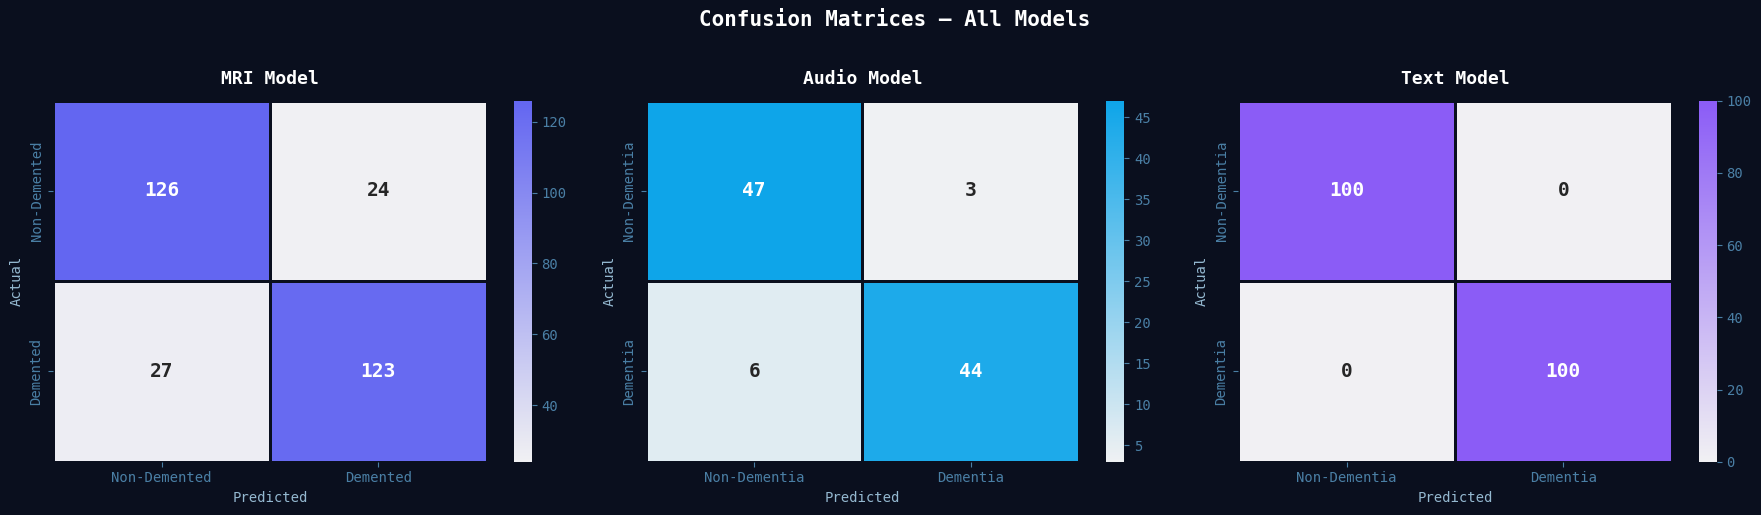

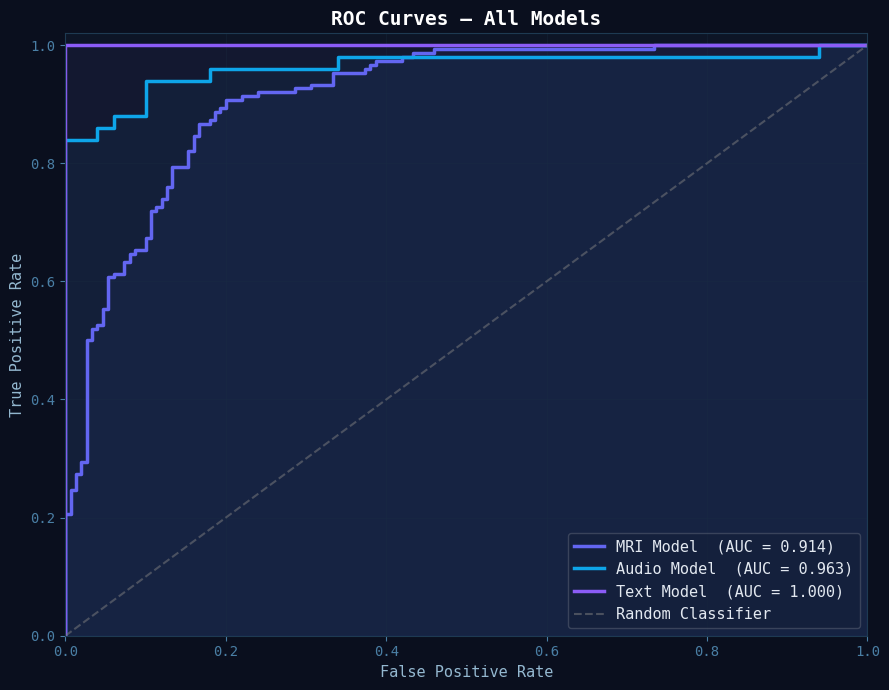

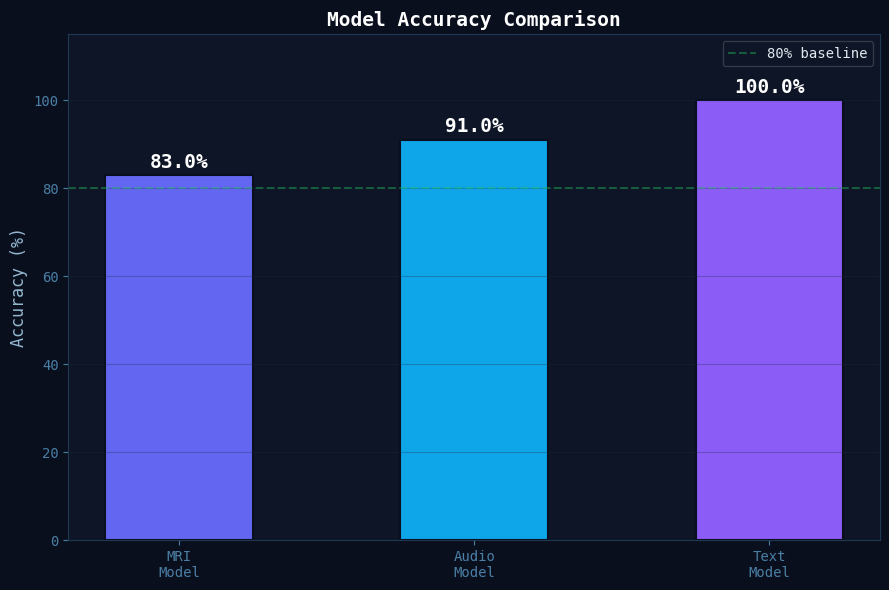

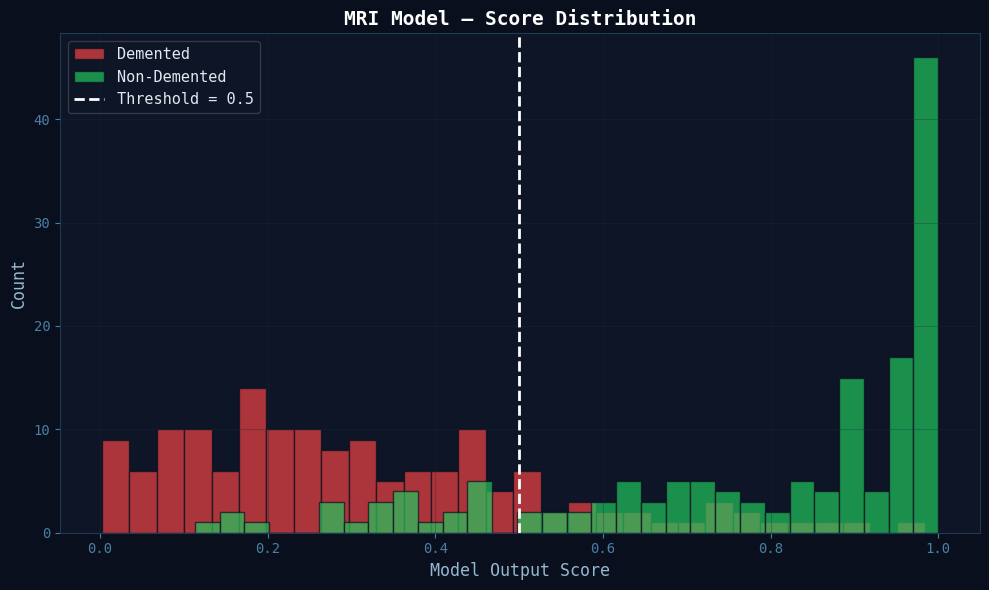

/tmp/ipykernel_1042/622255122.py:217: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1042/622255122.py:217: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1042/622255122.py:217: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1042/622255122.py:217: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1042/622255122.py:217: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing 

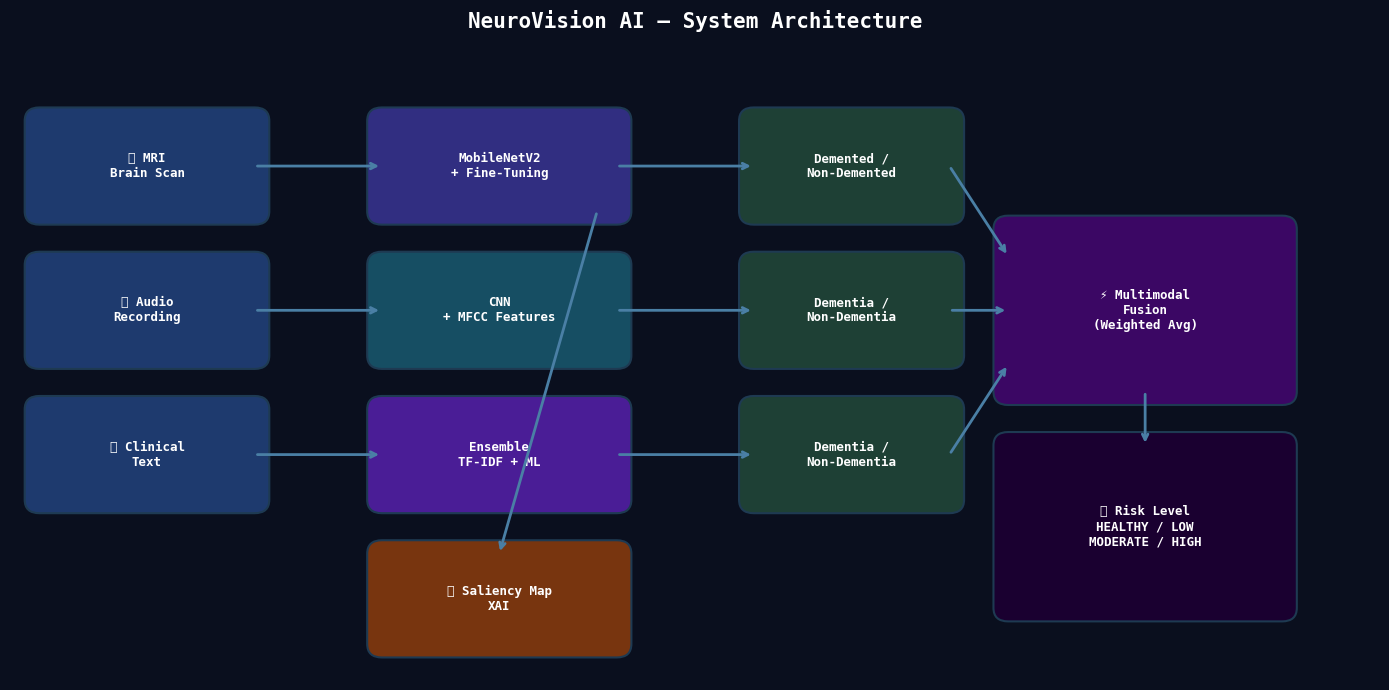

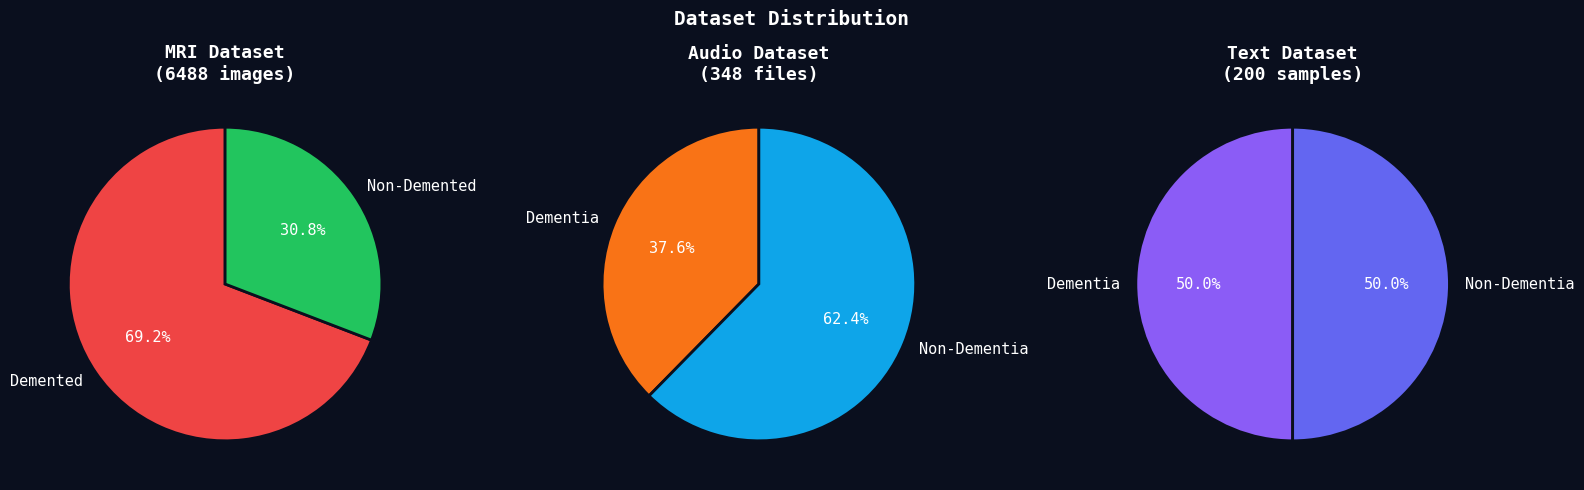

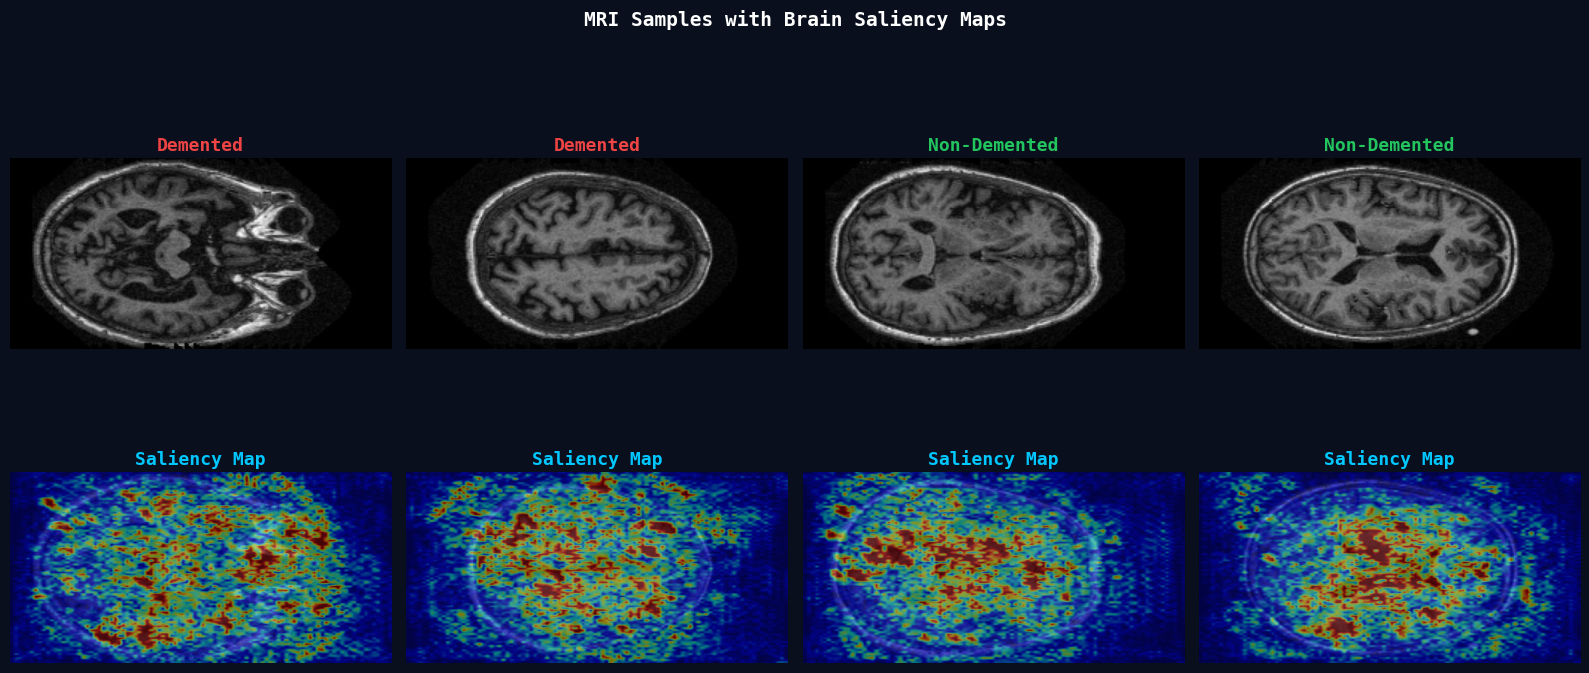


✅ All 7 plots displayed!
   Right-click any plot → Save image as...


In [ ]:
#  ALZHEIMER EARLY RISK SCREENING SYSTEM


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import glob, os, cv2, tensorflow as tf
from PIL import Image
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
import pandas as pd

plt.rcParams.update({
    'figure.facecolor': '#0a0f1e',
    'axes.facecolor':   '#0d1526',
    'axes.edgecolor':   '#1e3a52',
    'axes.labelcolor':  '#94b8d0',
    'xtick.color':      '#4a7fa5',
    'ytick.color':      '#4a7fa5',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1a2e42',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#ffffff',
})


print("📊 Evaluating models...")

# MRI
mri_scores, mri_true = [], []
for p in glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")[:150]:
    img = np.array(Image.open(p).convert("RGB").resize((96,96))).astype("float32")/255.0
    mri_scores.append(float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0]))
    mri_true.append(1)
for p in glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*.jpg")[:150]:
    img = np.array(Image.open(p).convert("RGB").resize((96,96))).astype("float32")/255.0
    mri_scores.append(float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0]))
    mri_true.append(0)
mri_pred = [1 if s < 0.5 else 0 for s in mri_scores]

# Audio
import librosa
audio_scores, audio_true = [], []
for f in glob.glob("/content/audio_dataset/dementia/**/*.wav", recursive=True)[:50]:
    try:
        y, sr = librosa.load(f, sr=22050, duration=30)
        mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        exp   = audio_model.input_shape[1]
        if exp == 120:
            mfcc = np.vstack([mfcc, librosa.feature.delta(mfcc), librosa.feature.delta(mfcc, order=2)])
        mfcc = np.pad(mfcc,((0,0),(0,max(0,300-mfcc.shape[1])))) if mfcc.shape[1]<300 else mfcc[:,:300]
        audio_scores.append(float(audio_model.predict(mfcc.reshape(1,exp,300,1), verbose=0)[0][0]))
        audio_true.append(1)
    except: pass
for f in glob.glob("/content/audio_dataset/nodementia/**/*.wav", recursive=True)[:50]:
    try:
        y, sr = librosa.load(f, sr=22050, duration=30)
        mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        exp   = audio_model.input_shape[1]
        if exp == 120:
            mfcc = np.vstack([mfcc, librosa.feature.delta(mfcc), librosa.feature.delta(mfcc, order=2)])
        mfcc = np.pad(mfcc,((0,0),(0,max(0,300-mfcc.shape[1])))) if mfcc.shape[1]<300 else mfcc[:,:300]
        audio_scores.append(float(audio_model.predict(mfcc.reshape(1,exp,300,1), verbose=0)[0][0]))
        audio_true.append(0)
    except: pass
audio_pred = [1 if s >= 0.5 else 0 for s in audio_scores]

# Text
df        = pd.read_csv("/content/drive/MyDrive/text_dataset.csv")
vec       = vectorizer.transform(df['text'])
text_prob = text_model.predict_proba(vec)[:,1] if hasattr(text_model,'predict_proba') else text_model.predict(vec)
text_pred = [1 if s >= 0.5 else 0 for s in text_prob]

print(f"MRI   Accuracy: {accuracy_score(mri_true, mri_pred)*100:.1f}%")
print(f"Audio Accuracy: {accuracy_score(audio_true, audio_pred)*100:.1f}%")
print(f"Text  Accuracy: {accuracy_score(df['label'], text_pred)*100:.1f}%")

# PLOT 1 — Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight='bold', color='white', y=1.02)

for ax, (yt, yp, title, labels, color) in zip(axes, [
    (mri_true,   mri_pred,   "MRI Model",   ['Non-Demented','Demented'], '#6366f1'),
    (audio_true, audio_pred, "Audio Model", ['Non-Dementia','Dementia'], '#0ea5e9'),
    (df['label'],text_pred,  "Text Model",  ['Non-Dementia','Dementia'], '#8b5cf6'),
]):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=labels, yticklabels=labels,
                linewidths=1, linecolor='#0a0f1e',
                annot_kws={'size':14,'weight':'bold'})
    ax.set_title(title, pad=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# PLOT 2 — ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))

for yt, ys, label, color in [
    (mri_true,   [1-s for s in mri_scores], "MRI Model",   '#6366f1'),
    (audio_true, audio_scores,               "Audio Model", '#0ea5e9'),
    (df['label'],text_prob,                  "Text Model",  '#8b5cf6'),
]:
    fpr, tpr, _ = roc_curve(yt, ys)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{label}  (AUC = {roc_auc:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

ax.plot([0,1],[0,1],'gray',linestyle='--',lw=1.5,alpha=0.5,label='Random Classifier')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate",  fontsize=11)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PLOT 3 — Accuracy Comparison
models = ['MRI\nModel','Audio\nModel','Text\nModel']
accs   = [accuracy_score(mri_true,mri_pred)*100,
          accuracy_score(audio_true,audio_pred)*100,
          accuracy_score(df['label'],text_pred)*100]
colors = ['#6366f1','#0ea5e9','#8b5cf6']

fig, ax = plt.subplots(figsize=(9,6))
bars = ax.bar(models, accs, color=colors, width=0.5, edgecolor='#0a0f1e', linewidth=1.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{acc:.1f}%', ha='center', va='bottom',
            fontsize=14, fontweight='bold', color='white')
ax.set_ylim(0, 115)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
ax.axhline(y=80, color='#22c55e', linestyle='--', alpha=0.4, lw=1.5, label='80% baseline')
ax.legend(fontsize=10, framealpha=0.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# PLOT 4 — Score Distribution

dem_s = [s for s,t in zip(mri_scores,mri_true) if t==1]
non_s = [s for s,t in zip(mri_scores,mri_true) if t==0]

fig, ax = plt.subplots(figsize=(10,6))
ax.hist(dem_s, bins=30, alpha=0.7, color='#ef4444', label='Demented',     edgecolor='#0a0f1e')
ax.hist(non_s, bins=30, alpha=0.7, color='#22c55e', label='Non-Demented', edgecolor='#0a0f1e')
ax.axvline(x=0.5, color='white', linestyle='--', lw=2, label='Threshold = 0.5')
ax.set_xlabel("Model Output Score", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("MRI Model — Score Distribution", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PLOT 5 — System Architecture

fig, ax = plt.subplots(figsize=(14,7))
ax.set_xlim(0,14); ax.set_ylim(0,7); ax.axis('off')

def box(ax,x,y,w,h,text,color):
    ax.add_patch(mpatches.FancyBboxPatch((x,y),w,h,
        boxstyle="round,pad=0.15",facecolor=color,
        edgecolor='#1e3a52',linewidth=1.5))
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',
            fontsize=9,color='white',fontweight='bold',multialignment='center')

def arrow(ax,x1,y1,x2,y2):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
        arrowprops=dict(arrowstyle='->',color='#4a7fa5',lw=2))

box(ax,0.3,5.2,2.2,1.0,"🧠 MRI\nBrain Scan",'#1e3a6e')
box(ax,0.3,3.6,2.2,1.0,"🎤 Audio\nRecording",'#1e3a6e')
box(ax,0.3,2.0,2.2,1.0,"📝 Clinical\nText",'#1e3a6e')
box(ax,3.8,5.2,2.4,1.0,"MobileNetV2\n+ Fine-Tuning",'#312e81')
box(ax,3.8,3.6,2.4,1.0,"CNN\n+ MFCC Features",'#164e63')
box(ax,3.8,2.0,2.4,1.0,"Ensemble\nTF-IDF + ML",'#4a1d96')
box(ax,7.6,5.2,2.0,1.0,"Demented /\nNon-Demented",'#1e4035')
box(ax,7.6,3.6,2.0,1.0,"Dementia /\nNon-Dementia",'#1e4035')
box(ax,7.6,2.0,2.0,1.0,"Dementia /\nNon-Dementia",'#1e4035')
box(ax,3.8,0.4,2.4,1.0,"🔥 Saliency Map\nXAI",'#78350f')
box(ax,10.2,3.2,2.8,1.8,"⚡ Multimodal\nFusion\n(Weighted Avg)",'#3b0764')
box(ax,10.2,0.8,2.8,1.8,"🏥 Risk Level\nHEALTHY / LOW\nMODERATE / HIGH",'#1a0030')

for y in [5.7,4.1,2.5]:
    arrow(ax,2.5,y,3.8,y)
    arrow(ax,6.2,y,7.6,y)
arrow(ax,9.6,5.7,10.2,4.7)
arrow(ax,9.6,4.1,10.2,4.1)
arrow(ax,9.6,2.5,10.2,3.5)
arrow(ax,11.6,3.2,11.6,2.6)
arrow(ax,6.0,5.2,5.0,1.4)

ax.set_title("NeuroVision AI — System Architecture",
             fontsize=15, fontweight='bold', color='white', pad=15)
plt.tight_layout()
plt.show()

# PLOT 6 — Dataset Distribution
fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle("Dataset Distribution", fontsize=14, fontweight='bold', color='white')

d_mri = len(glob.glob("/content/BINARY_MRI_DATASET/Demented/*"))
n_mri = len(glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*"))
axes[0].pie([d_mri,n_mri],labels=['Demented','Non-Demented'],
            colors=['#ef4444','#22c55e'],autopct='%1.1f%%',startangle=90,
            wedgeprops={'edgecolor':'#0a0f1e','linewidth':2},
            textprops={'color':'white','fontsize':11})
axes[0].set_title(f"MRI Dataset\n({d_mri+n_mri} images)")

d_aud = len(glob.glob("/content/audio_dataset/dementia/**/*.wav",recursive=True))
n_aud = len(glob.glob("/content/audio_dataset/nodementia/**/*.wav",recursive=True))
axes[1].pie([d_aud,n_aud],labels=['Dementia','Non-Dementia'],
            colors=['#f97316','#0ea5e9'],autopct='%1.1f%%',startangle=90,
            wedgeprops={'edgecolor':'#0a0f1e','linewidth':2},
            textprops={'color':'white','fontsize':11})
axes[1].set_title(f"Audio Dataset\n({d_aud+n_aud} files)")

d_txt = int(df['label'].sum()); n_txt = len(df)-d_txt
axes[2].pie([d_txt,n_txt],labels=['Dementia','Non-Dementia'],
            colors=['#8b5cf6','#6366f1'],autopct='%1.1f%%',startangle=90,
            wedgeprops={'edgecolor':'#0a0f1e','linewidth':2},
            textprops={'color':'white','fontsize':11})
axes[2].set_title(f"Text Dataset\n({len(df)} samples)")

plt.tight_layout()
plt.show()

# PLOT 7 — MRI Samples + Saliency Maps
samples  = (glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")[:2] +
            glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*.jpg")[:2])
labels_s = ['Demented','Demented','Non-Demented','Non-Demented']

fig, axes = plt.subplots(2, 4, figsize=(16,8))
fig.suptitle("MRI Samples with Brain Saliency Maps",
             fontsize=14, fontweight='bold', color='white')

for i,(path,lbl) in enumerate(zip(samples,labels_s)):
    pil_img = Image.open(path).convert("RGB")
    axes[0][i].imshow(pil_img)
    axes[0][i].set_title(lbl, color='#ef4444' if 'Non' not in lbl else '#22c55e', fontweight='bold')
    axes[0][i].axis('off')

    img    = np.array(pil_img.resize((96,96))).astype("float32")/255.0
    img_tf = tf.Variable(np.expand_dims(img,0))
    with tf.GradientTape() as tape:
        tape.watch(img_tf)
        loss = mri_model(img_tf, training=False)[:,0]
    grads   = tape.gradient(loss, img_tf).numpy()[0]
    heatmap = np.mean(np.abs(grads), axis=-1)
    p5,p95  = np.percentile(heatmap,5), np.percentile(heatmap,95)
    heatmap = np.clip(heatmap,p5,p95)
    heatmap = (heatmap-heatmap.min())/(heatmap.max()-heatmap.min()+1e-8)
    axes[1][i].imshow(np.array(pil_img), alpha=0.6)
    axes[1][i].imshow(cv2.resize(heatmap,(pil_img.size[0],pil_img.size[1])),
                      cmap='jet', alpha=0.5)
    axes[1][i].set_title("Saliency Map", color='#00c8ff')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ All 7 plots displayed!")
print("   Right-click any plot → Save image as...")

In [ ]:
# تقييم شامل لكل النماذج
import numpy as np
import glob
from PIL import Image
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score,
    precision_score, recall_score
)
import librosa
import pandas as pd

print("="*60)
print("  COMPLETE MODEL EVALUATION — ALL METRICS")
print("="*60)



# ============================================================
# 2. AUDIO MODEL
# ============================================================
print("\n🎤 AUDIO MODEL EVALUATION")
print("-"*40)

audio_scores, audio_true = [], []
exp = audio_model.input_shape[1]

dem_audio = glob.glob("/content/audio_dataset/dementia/**/*.wav", recursive=True)
non_audio = glob.glob("/content/audio_dataset/nodementia/**/*.wav", recursive=True)

print(f"  Total Dementia files    : {len(dem_audio)}")
print(f"  Total NonDementia files : {len(non_audio)}")
print(f"  Total files             : {len(dem_audio)+len(non_audio)}")

for f in dem_audio:
    try:
        y, sr = librosa.load(f, sr=22050, duration=30)
        mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        if exp == 120:
            mfcc = np.vstack([mfcc, librosa.feature.delta(mfcc),
                              librosa.feature.delta(mfcc, order=2)])
        mfcc = np.pad(mfcc,((0,0),(0,max(0,300-mfcc.shape[1])))) \
               if mfcc.shape[1]<300 else mfcc[:,:300]
        s = float(audio_model.predict(mfcc.reshape(1,exp,300,1), verbose=0)[0][0])
        audio_scores.append(s); audio_true.append(1)
    except: pass

for f in non_audio:
    try:
        y, sr = librosa.load(f, sr=22050, duration=30)
        mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        if exp == 120:
            mfcc = np.vstack([mfcc, librosa.feature.delta(mfcc),
                              librosa.feature.delta(mfcc, order=2)])
        mfcc = np.pad(mfcc,((0,0),(0,max(0,300-mfcc.shape[1])))) \
               if mfcc.shape[1]<300 else mfcc[:,:300]
        s = float(audio_model.predict(mfcc.reshape(1,exp,300,1), verbose=0)[0][0])
        audio_scores.append(s); audio_true.append(0)
    except: pass

audio_pred = [1 if s >= 0.5 else 0 for s in audio_scores]

print(f"\n  Accuracy  : {accuracy_score(audio_true, audio_pred)*100:.2f}%")
print(f"  AUC       : {roc_auc_score(audio_true, audio_scores):.4f}")
print(f"  Precision : {precision_score(audio_true, audio_pred):.4f}")
print(f"  Recall    : {recall_score(audio_true, audio_pred):.4f}")
print(f"  F1-Score  : {f1_score(audio_true, audio_pred):.4f}")
print(f"\n  Confusion Matrix:")
cm = confusion_matrix(audio_true, audio_pred)
print(f"  TN={cm[0][0]}  FP={cm[0][1]}")
print(f"  FN={cm[1][0]}  TP={cm[1][1]}")
print(f"\n  Classification Report:")
print(classification_report(audio_true, audio_pred,
      target_names=['NonDementia','Dementia']))

# ============================================================
# 3. TEXT MODEL
# ============================================================
print("\n📝 TEXT MODEL EVALUATION")
print("-"*40)

df = pd.read_csv("/content/drive/MyDrive/text_dataset.csv")
print(f"  Total samples           : {len(df)}")
print(f"  Dementia samples        : {df['label'].sum()}")
print(f"  NonDementia samples     : {len(df)-df['label'].sum()}")

vec        = vectorizer.transform(df['text'])
text_prob  = text_model.predict_proba(vec)[:,1] \
             if hasattr(text_model,'predict_proba') \
             else text_model.predict(vec)
text_pred  = [1 if s >= 0.5 else 0 for s in text_prob]
text_true  = df['label'].tolist()

print(f"\n  Accuracy  : {accuracy_score(text_true, text_pred)*100:.2f}%")
print(f"  AUC       : {roc_auc_score(text_true, text_prob):.4f}")
print(f"  Precision : {precision_score(text_true, text_pred):.4f}")
print(f"  Recall    : {recall_score(text_true, text_pred):.4f}")
print(f"  F1-Score  : {f1_score(text_true, text_pred):.4f}")
print(f"\n  Confusion Matrix:")
cm = confusion_matrix(text_true, text_pred)
print(f"  TN={cm[0][0]}  FP={cm[0][1]}")
print(f"  FN={cm[1][0]}  TP={cm[1][1]}")
print(f"\n  Classification Report:")
print(classification_report(text_true, text_pred,
      target_names=['NonDementia','Dementia']))



  COMPLETE MODEL EVALUATION — ALL METRICS

🎤 AUDIO MODEL EVALUATION
----------------------------------------
  Total Dementia files    : 131
  Total NonDementia files : 217
  Total files             : 348

  Accuracy  : 91.59%
  AUC       : 0.9664
  Precision : 0.9091
  Recall    : 0.8594
  F1-Score  : 0.8835

  Confusion Matrix:
  TN=206  FP=11
  FN=18  TP=110

  Classification Report:
              precision    recall  f1-score   support

 NonDementia       0.92      0.95      0.93       217
    Dementia       0.91      0.86      0.88       128

    accuracy                           0.92       345
   macro avg       0.91      0.90      0.91       345
weighted avg       0.92      0.92      0.92       345


📝 TEXT MODEL EVALUATION
----------------------------------------
  Total samples           : 200
  Dementia samples        : 100
  NonDementia samples     : 100

  Accuracy  : 100.00%
  AUC       : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

  Confusion M

In [ ]:

# Dataset Statistics — أعداد البيانات الكاملة

import glob
import os
import pandas as pd

print("="*55)
print("  DATASET STATISTICS — Complete Summary")
print("="*55)

# 1. MRI Dataset

print("\n🧠 MRI DATASET")
print("-"*40)

dem_imgs = glob.glob("/content/BINARY_MRI_DATASET/Demented/*")
non_imgs = glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*")
total_mri = len(dem_imgs) + len(non_imgs)

print(f"  Demented     : {len(dem_imgs)} images  ({len(dem_imgs)/total_mri*100:.1f}%)")
print(f"  NonDemented  : {len(non_imgs)} images  ({len(non_imgs)/total_mri*100:.1f}%)")
print(f"  Total        : {total_mri} images")

# 2. Audio Dataset
print("\n🎤 AUDIO DATASET")
print("-"*40)

dem_audio = glob.glob("/content/audio_dataset/dementia/**/*.wav", recursive=True)
non_audio = glob.glob("/content/audio_dataset/nodementia/**/*.wav", recursive=True)
total_audio = len(dem_audio) + len(non_audio)

print(f"  Dementia     : {len(dem_audio)} files  ({len(dem_audio)/total_audio*100:.1f}%)")
print(f"  NonDementia  : {len(non_audio)} files  ({len(non_audio)/total_audio*100:.1f}%)")
print(f"  Total        : {total_audio} files")

# عدد المتكلمين
dem_speakers = len(os.listdir("/content/audio_dataset/dementia"))
non_speakers = len(os.listdir("/content/audio_dataset/nodementia"))
print(f"\n  Dementia Speakers    : {dem_speakers}")
print(f"  NonDementia Speakers : {non_speakers}")
print(f"  Total Speakers       : {dem_speakers + non_speakers}")

# 3. Text Dataset

print("\n📝 TEXT DATASET")
print("-"*40)

df = pd.read_csv("/content/drive/MyDrive/text_dataset.csv")
dem_text = int(df['label'].sum())
non_text = len(df) - dem_text

print(f"  Dementia     : {dem_text} samples  ({dem_text/len(df)*100:.1f}%)")
print(f"  NonDementia  : {non_text} samples  ({non_text/len(df)*100:.1f}%)")
print(f"  Total        : {len(df)} samples")
print(f"  Avg text length: {df['text'].str.split().str.len().mean():.1f} words")
print(f"  Max text length: {df['text'].str.split().str.len().max()} words")
print(f"  Min text length: {df['text'].str.split().str.len().min()} words")

# Final Summary Table
print("\n" + "="*55)
print("  FINAL SUMMARY TABLE")
print("="*55)
print(f"  {'Modality':<12} {'Class 0':<18} {'Class 1':<18} {'Total'}")
print(f"  {'-'*50}")
print(f"  {'MRI':<12} {'NonDemented: '+str(len(non_imgs)):<18} {'Demented: '+str(len(dem_imgs)):<18} {total_mri}")
print(f"  {'Audio':<12} {'NonDementia: '+str(len(non_audio)):<18} {'Dementia: '+str(len(dem_audio)):<18} {total_audio}")
print(f"  {'Text':<12} {'NonDementia: '+str(non_text):<18} {'Dementia: '+str(dem_text):<18} {len(df)}")
print("="*55)

  DATASET STATISTICS — Complete Summary

🧠 MRI DATASET
----------------------------------------
  Demented     : 4488 images  (69.2%)
  NonDemented  : 2000 images  (30.8%)
  Total        : 6488 images

🎤 AUDIO DATASET
----------------------------------------
  Dementia     : 131 files  (37.6%)
  NonDementia  : 217 files  (62.4%)
  Total        : 348 files

  Dementia Speakers    : 84
  NonDementia Speakers : 95
  Total Speakers       : 179

📝 TEXT DATASET
----------------------------------------
  Dementia     : 100 samples  (50.0%)
  NonDementia  : 100 samples  (50.0%)
  Total        : 200 samples
  Avg text length: 8.0 words
  Max text length: 11 words
  Min text length: 6 words

  FINAL SUMMARY TABLE
  Modality     Class 0            Class 1            Total
  --------------------------------------------------
  MRI          NonDemented: 2000  Demented: 4488     6488
  Audio        NonDementia: 217   Dementia: 131      348
  Text         NonDementia: 100   Dementia: 100      200


In [ ]:
# MRI Model — Complete Accuracy & Metrics

import numpy as np
import glob
from PIL import Image
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score
)

print("="*50)
print("  MRI MODEL — FULL EVALUATION")
print("="*50)

mri_scores, mri_true = [], []

dem_imgs = glob.glob("/content/BINARY_MRI_DATASET/Demented/*.jpg")
non_imgs = glob.glob("/content/BINARY_MRI_DATASET/NonDemented/*.jpg")

print(f"  Demented     : {len(dem_imgs)} images")
print(f"  NonDemented  : {len(non_imgs)} images")
print(f"  Total        : {len(dem_imgs)+len(non_imgs)} images")
print("\n  Evaluating... (takes 1-2 min)")

for p in dem_imgs:
    img = np.array(Image.open(p).convert("RGB").resize((96,96))).astype("float32")/255.0
    s   = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    mri_scores.append(s); mri_true.append(1)

for p in non_imgs:
    img = np.array(Image.open(p).convert("RGB").resize((96,96))).astype("float32")/255.0
    s   = float(mri_model.predict(np.expand_dims(img,0), verbose=0)[0][0])
    mri_scores.append(s); mri_true.append(0)

mri_pred = [1 if s < 0.5 else 0 for s in mri_scores]

print(f"\n  Accuracy  : {accuracy_score(mri_true, mri_pred)*100:.2f}%")
print(f"  AUC       : {roc_auc_score(mri_true, [1-s for s in mri_scores]):.4f}")
print(f"  Precision : {precision_score(mri_true, mri_pred):.4f}")
print(f"  Recall    : {recall_score(mri_true, mri_pred):.4f}")
print(f"  F1-Score  : {f1_score(mri_true, mri_pred):.4f}")

cm = confusion_matrix(mri_true, mri_pred)
print(f"\n  Confusion Matrix:")
print(f"  TN={cm[0][0]}  FP={cm[0][1]}")
print(f"  FN={cm[1][0]}  TP={cm[1][1]}")

print(f"\n{classification_report(mri_true, mri_pred, target_names=['NonDemented','Demented'])}")

  MRI MODEL — FULL EVALUATION
  Demented     : 4488 images
  NonDemented  : 2000 images
  Total        : 6488 images

  Evaluating... (takes 1-2 min)

  Accuracy  : 84.86%
  AUC       : 0.8859
  Precision : 0.8586
  Recall    : 0.9352
  F1-Score  : 0.8953

  Confusion Matrix:
  TN=1309  FP=691
  FN=291  TP=4197

              precision    recall  f1-score   support

 NonDemented       0.82      0.65      0.73      2000
    Demented       0.86      0.94      0.90      4488

    accuracy                           0.85      6488
   macro avg       0.84      0.79      0.81      6488
weighted avg       0.85      0.85      0.84      6488

